 # Trajectory analysis
 
This notebook is created to analyse the trajectory case series of the `SCENES` project.

## Imports and functions

In [1]:
import os
import re
import datetime
import math
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
# from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, LogLocator, FuncFormatter,  AutoMinorLocator , FixedLocator, LogFormatterMathtext
from pdf2image import convert_from_path
from matplotlib import rcParams
from matplotlib.patches import Rectangle
from cmcrameri import cm     #Scientific color maps
from itertools import cycle
from scipy.stats import ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import csv 
import gc
import random
from PIL import Image
from IPython.display import display, Markdown
import inspect

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [3]:
# Set default font properties
rcParams['font.family'] = 'Arial'
# Disable LaTeX rendering for text
rcParams['text.usetex'] = False  # This prevents LaTeX formatting in the tick labels
rcParams['font.size'] = 12

In [4]:
# Root path- project directory
root_dir = os.path.abspath("..")

In [5]:
# Color palettes

# Choose the color palette from cmcrameri
cmap = cm.batlow

# Define the custom color palette for photoreceptors
photoreceptor_colors = {
    'L cones': (0.8941, 0.1020, 0.1098),
    'M cones': (0.3020, 0.6863, 0.2902),
    'S cones': (0.2157, 0.4941, 0.7216),
    'Rods': (0.0157, 0.4118, 0.3333),
    'Melanopsin': (0.1255, 0.6549, 0.7686)   
}

### Functions

In [6]:
# =========================================================
# Function for plotting the distribution of mean melanopic value of synthetic sequences
# =========================================================

def plot_model_timeline_iqr(
    sequences,
    placeholders=None,
    times=None,
    base_color=None,
    metric_name="Melanopic ED (lx)I",
    sequences_name=None,
    save_dir="../results/plots",
    dpi=300,
    show_median=False,
    ax=None,
    save=True,
    add_top_axis=True,
    show_legend=True,
):

    sequences = np.asarray(sequences)
    n_slots, _ = sequences.shape

    if placeholders is None:
        placeholders = [f"PH{i+1:02d}" for i in range(n_slots)]
    if len(placeholders) != n_slots:
        raise ValueError("Length of `placeholders` must match sequences.shape[0].")

    x = np.arange(n_slots)

    mean = sequences.mean(axis=1)
    ymin = sequences.min(axis=1)
    ymax = sequences.max(axis=1)
    q25 = np.percentile(sequences, 25, axis=1)
    q75 = np.percentile(sequences, 75, axis=1)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
        created_fig = True
    else:
        fig = ax.figure

    if base_color is None:
        base_color = cm.batlow(0.6)

    # Range
    ax.fill_between(
        x, ymin, ymax,
        color=base_color, alpha=0.3,
        edgecolor="black", linewidth=0.5,
        label="Range", zorder=3
    )

    # IQR
    ax.fill_between(
        x, q25, q75,
        color=base_color, alpha=0.7,
        edgecolor="black", linewidth=0.5,
        label="IQR", zorder=5
    )

    # Mean
    ax.plot(
        x, mean,
        linewidth=2,
        marker="o",
        color="black",
        markerfacecolor=base_color,
        markeredgecolor="black",
        markeredgewidth=0.6,
        label="Mean",
        zorder=7
    )

    if show_median:
        med = np.median(sequences, axis=1)
        ax.plot(x, med, linestyle="-", marker=None, label="Median")

    # Bottom x-axis
    ax.set_xticks(x)
    ax.set_xticklabels(placeholders, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Placeholder", fontsize=11)

    # Top x-axis
    ax_top = None
    if add_top_axis and (times is not None):
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(x)
        ax_top.set_xticklabels(times, rotation=45, ha="left", fontsize=9)
        ax_top.set_xlabel("Time of day", fontsize=11)

    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 1e5)
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.tick_params(axis="y", labelsize=10)

    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    if show_legend:
        leg = ax.legend(
            loc="lower center",
            fontsize=9,
            frameon=False,
            handlelength=2,
            title=sequences_name
        )
        if leg and leg.get_title():
            leg.get_title().set_fontsize(10)

    if created_fig:
        plt.tight_layout()

    if save and sequences_name:
        os.makedirs(save_dir, exist_ok=True)
        safe = str(sequences_name).replace(" ", "_")
        base = f"{save_dir}/Distribution_{safe}"
        fig.savefig(base + ".png", bbox_inches="tight", dpi=dpi)
        fig.savefig(base + ".pdf", bbox_inches="tight", dpi=dpi)

    stats = {"mean": mean, "q25": q25, "q75": q75}
    if show_median:
        stats["median"] = np.median(sequences, axis=1)

    return stats, ax_top


In [7]:
# =========================================================
# Function for plotting the heatmap of median reletive error heatmap (monte carlo convergence) for differnt numbers of synthetic sequences
# =========================================================

def plot_monte_carlo_stability_heatmap(
    sequences,
    repeats=(100, 1000, 10000, 100000),
    n_runs=50,
    rel_threshold=0.01,
    metric_name="Melanopic-EDI",
    sequences_name=None,
    placeholders=None,
    seed=123,
    reference="full",        
    save_dir="../results/plots",
    dpi=300,
    vmax=5.0,
):
    """
    Heatmap of Monte Carlo convergence (median relative error, %) per placeholder.
    - X axis: placeholders
    - Y axis: repeats (r)
    - Cell value: median relative error (%) across n_runs
    - Fixed vmax (%) for comparability across models
    """
    sequences = np.asarray(sequences)
    n_slots, n_seq = sequences.shape
    repeats = list(repeats)

    if placeholders is None:
        placeholders = [f"PH{i+1:02d}" for i in range(n_slots)]
    if len(placeholders) != n_slots:
        raise ValueError("Length of `placeholders` must match sequences.shape[0].")

    rng = np.random.default_rng(seed)
    # Reference mean: full set
    ref_mean = sequences.mean(axis=1)

    # all_err: run x repeat x slot
    all_err = np.zeros((n_runs, len(repeats), n_slots), dtype=float)

    for j, r in enumerate(repeats):
        r_eff = min(int(r), n_seq)
        for b in range(n_runs):
            # Subsample already-generated sequences (columns)
            idx = rng.choice(n_seq, size=r_eff, replace=False)
            mean_r = sequences[:, idx].mean(axis=1)
            rel_err = np.abs(mean_r - ref_mean) / (np.abs(ref_mean) + 1e-12)
            all_err[b, j, :] = rel_err

    # Median across runs -> % ; shape: repeats x slots
    median_err = np.median(all_err, axis=0) * 100.0

    # ---- Plot  ----
    fig, ax = plt.subplots(figsize=(7, 3))

    im = ax.imshow(
        median_err,
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=float(vmax),
        cmap=cm.batlow,
        alpha=0.9
    )

    # Axes: X = placeholders, Y = repeats
    ax.set_yticks(np.arange(len(repeats)))
    ax.set_yticklabels([rf"$10^{{{np.log10(r):.0f}}}$" for r in repeats], fontsize=9)
    ax.set_ylabel("Number of synthetic sequences ", fontsize=10)

    ax.set_xticks(np.arange(n_slots))
    ax.set_xticklabels(placeholders, rotation=45, ha="center", fontsize=8)
    ax.set_xlabel("Placeholder", fontsize=11)

    # Add thin borders around each cell
    ax.set_xticks(np.arange(-0.5, n_slots, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(repeats), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ax.set_title(f"Monte Carlo convergence (median relative error, %) — {metric_name}", fontsize=11)

    # Mark cells meeting criterion (< threshold)
    thr_pct = rel_threshold * 100.0
    ok = median_err < thr_pct
    ys, xs = np.where(ok)
    ax.scatter(xs, ys, s=20, marker="o", facecolors="none", edgecolors="black", linewidths=0.8)

    # Text box: first line = sequence name, second line = criterion
    if sequences_name is None:
        seq_title = "Model"
    else:
        seq_title = str(sequences_name)

    ax.text(
        0.01, 0.99,
        f"Open circles: median relative error < {thr_pct:.1f}%",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.6", alpha=0.9)
    )

    # Compact colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Median relative error (%)", rotation=90, fontsize=9)

    plt.tight_layout()

    # Save
    if sequences_name:
        safe_name = str(sequences_name).replace(" ", "_")
        file_base = f"{save_dir}/MonteCarlo_convergence_heatmap_{safe_name}"
        fig.savefig(file_base + ".png", bbox_inches="tight", dpi=dpi)
        fig.savefig(file_base + ".pdf", bbox_inches="tight", dpi=dpi)

    return median_err, all_err

In [8]:
# =========================================================
# Function for plotting four metrics as a violin plot for any models
# =========================================================

def plot_model_metrics_violin(df, model_name, color=None, save_dir=None, dpi=300, bw=0.5, ax=None):
    dose_col = "dose"
    duration_cols = [
        "duration_above_250",
        "duration_above_1000",
        "duration_above_10000"
    ]
    duration_labels = [
        "TAT>250 lx",
        "TAT>1000 lx",
        "TAT>10000 lx"
    ]

    if ax is None:
        fig, axs = plt.subplots(
            2, 1,
            figsize=(6, 4),
            gridspec_kw={"height_ratios": [1, 2], "hspace": 0.6}
        )
    else:
        axs = ax
        fig = axs[0].figure

    # Dose subplot
    dose_parts = axs[0].violinplot(
        [df[dose_col].dropna().values],
        vert=False,
        showmedians=True,
        showextrema=False,
        bw_method=bw
    )

    for body in dose_parts["bodies"]:
        if color is not None:
            body.set_facecolor(color)
        else:
            body.set_facecolor("none")
        body.set_edgecolor("black")
        body.set_alpha(0.9)

    dose_parts["cmedians"].set_color("black")
    dose_parts["cmedians"].set_linewidth(1.5)

    axs[0].set_axisbelow(True)
    axs[0].set_xscale("log")
    axs[0].set_xlim(1e3, 1e6)

    axs[0].xaxis.set_major_locator(LogLocator(base=10))
    axs[0].xaxis.set_major_formatter(LogFormatterMathtext(base=10))
    axs[0].tick_params(labelsize=9)
    axs[0].set_yticks([1])
    axs[0].set_yticklabels(["Dose"], fontsize=11)
    axs[0].set_xlabel("Melanopic dose (lx·h)", fontsize=11)

    axs[0].grid(axis="x", which="major", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
    axs[0].grid(axis="x", which="minor", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)

    # Duration subplot
    duration_data = [
        (df[col] / 3600).dropna().values for col in duration_cols
    ]

    duration_parts = axs[1].violinplot(
        duration_data,
        vert=False,
        showmedians=True,
        showextrema=False,
        bw_method=bw
    )

    for body in duration_parts["bodies"]:
        if color is not None:
            body.set_facecolor(color)
        else:
            body.set_facecolor("none")
        body.set_edgecolor("black")
        body.set_alpha(0.9)

    duration_parts["cmedians"].set_color("black")
    duration_parts["cmedians"].set_linewidth(1.5)

    axs[1].set_axisbelow(True)
    axs[1].tick_params(labelsize=9)
    axs[1].set_yticks(range(1, len(duration_labels) + 1))
    axs[1].set_yticklabels(duration_labels, fontsize=10)
    axs[1].set_xlabel("Duration (h)", fontsize=11)
    axs[1].set_xlim(-0.5, 12.5)

    axs[1].xaxis.set_major_locator(MultipleLocator(1))
    axs[1].xaxis.set_minor_locator(MultipleLocator(1 / 6))
    axs[1].tick_params(axis="x", which="minor", length=2, labelbottom=False)

    # Legend
    median_handle = Line2D([0], [0], color="black", lw=1.5, label="Median")
    axs[1].legend(
        handles=[median_handle],
        loc="upper right",
        frameon=True,
        framealpha=0.7,
        fontsize=8,
        title=f"{model_name}",
        title_fontsize=9
    )

    axs[1].grid(axis="x", which="major", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
    axs[1].grid(axis="x", which="minor", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        safe = model_name.replace(" ", "_")
        base = f"{save_dir}/Metrics_{safe}"
        fig.savefig(base + ".png", bbox_inches="tight", dpi=dpi)
        fig.savefig(base + ".pdf", bbox_inches="tight", dpi=dpi)

    stats = {
        "dose": {
            "median": df[dose_col].dropna().median(),
            "min": df[dose_col].dropna().min(),
            "max": df[dose_col].dropna().max(),
        }
    }

    for col, label in zip(duration_cols, duration_labels):
        vals_h = (df[col] / 3600).dropna()
        stats[label] = {
            "median": vals_h.median(),
            "min": vals_h.min(),
            "max": vals_h.max(),
        }
    return fig, axs, stats

## Environmental spectral illuminance from Canada at three trajectory days

In [9]:
# Import environmental datasets

paths = [
    os.path.join(root_dir, "data", "20230614RoofBox1min.csv"),
    os.path.join(root_dir, "data", "20230616RoofBox1min.csv"),
    os.path.join(root_dir, "data", "20230619RoofBox1min.csv"),
]

env_illuminance_14_df , env_illuminance_16_df , env_illuminance_19_df= map(pd.read_csv, paths)

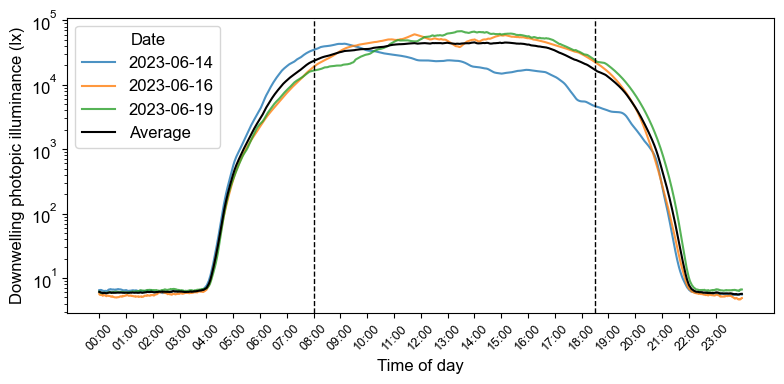

In [10]:
# Plot downwelling photopic illuminance for trajectory days (log scale )

plt.figure(figsize=(8, 4))

smoothed_series = []

for df in (env_illuminance_14_df, env_illuminance_16_df, env_illuminance_19_df):
    df = df.copy()
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.sort_values("DateTime")

    x = df["DateTime"].dt.strftime("%H:%M")
    y = df["Out Ill (Lux)"]

    y_smooth = y.rolling(window=100, center=True, min_periods=1).mean()
    smoothed_series.append(y_smooth.values)

    label = df["DateTime"].dt.date.iloc[0].isoformat()
    plt.plot(x, y_smooth, alpha=0.8, label=label)

# --- average line ---
avg_y = np.mean(smoothed_series, axis=0)
plt.plot(x, avg_y, color="black", linewidth=1.5, label="Average")

# x-ticks every 1 hour (1-min data)
tick_pos = list(range(0, len(x), 60))
tick_lab = x.iloc[::60]
plt.xticks(tick_pos, tick_lab, rotation=45,fontsize=9)
plt.yscale('log')
plt.xlabel("Time of day")
plt.ylabel("Downwelling photopic illuminance (lx)")

plt.legend(title="Date")

# --- vertical reference lines ---
time_labels = x.tolist()

idx_0800 = time_labels.index("08:00")
idx_1830 = time_labels.index("18:30")

plt.axvline(idx_0800, color="black", linestyle="--", linewidth=1)
plt.axvline(idx_1830, color="black", linestyle="--", linewidth=1)

plt.tight_layout()

## Import Jeti-metadata file


In [11]:
# Dataset for merged metadata and spectral data (Jeti)

merged_metadata_jeti_df = pd.read_csv(
    os.path.join(root_dir, "data", "metadata_jeti_scenes.csv"),
    index_col=0,
    dtype={'time': str}
)

# Replace all NaN cells with blanks
merged_metadata_jeti_df = merged_metadata_jeti_df.fillna('')
merged_metadata_jeti_df.head()

,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,date_x,time_x,protocol,available_$device,available_gloptic_spectis1,available_gigahertz-optic_msc15,available_jeti_spectraval1511,available_westborophotonics_wp690e-circ,wp690csv,available_kleininstruments_k-10a,available_inteldrealsense_d455,available_gopro_hero10black_video,available_gopro_hero10black_photo,location,latitude,longitude,direction,elevation,groundheight,boxtilt,boxheight,temperature,humidity,weather,other_weather,wind,scene,other_scene,view,other_view,lighting,other_lighting,technotes,available_all,date_y,time_y,Illuminance [lx] (CIE1931 2°),Irradiance [W/sqm] (380-780nm),Correlated Color Temp. (CCT) [K],Duv,dE2000 (CIE1931 2°),Dominant Wavelength (DWl) [nm] (CIE1931 2°),Color Purity (PE) [%] (CIE1931 2°),x,y,X,Y,Z,dE00,CCT [K],R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,Ra,Re,DC,VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8,VS9,VS10,VS11,VS12,VS13,VS14,VS15,Qa,Qf,Qp,Qg,Rf,Rg,Rf (general color fidelity index),Rf1,Rf2,Rf3,Rf4,Rf5,Rf6,Rf7,Rf8,Rf9,Rf10,Rf11,Rf12,Rf13,Rf14,Rf15,Rf16,Rf17,Rf18,Rf19,Rf20,Rf21,Rf22,Rf23,Rf24,Rf25,Rf26,Rf27,Rf28,Rf29,Rf30,Rf31,Rf32,Rf33,Rf34,Rf35,Rf36,Rf37,Rf38,Rf39,Rf40,Rf41,Rf42,Rf43,Rf44,Rf45,Rf46,Rf47,Rf48,Rf49,Rf50,Rf51,Rf52,Rf53,Rf54,Rf55,Rf56,Rf57,Rf58,Rf59,Rf60,Rf61,Rf62,Rf63,Rf64,Rf65,Rf66,Rf67,Rf68,Rf69,Rf70,Rf71,Rf72,Rf73,Rf74,Rf75,Rf76,Rf77,Rf78,Rf79,Rf80,Rf81,Rf82,Rf83,Rf84,Rf85,Rf86,Rf87,Rf88,Rf89,Rf90,Rf91,Rf92,Rf93,Rf94,Rf95,Rf96,Rf97,Rf98,Rf99,Begin Wavelength [nm],End Wavelength [nm],Ephot (Begin..End) [uMol/s sqm],"X e,mel [W/sqm]","X v,mel,D65 (MEDI) [lx]","a mel,v (MEER)","m v,mel,D65 (MDER)",EML [lx],CCT [K].1,Esc [W/sqm],Emc [W/sqm],Elc [W/sqm],Erh [W/sqm],Emel [W/sqm],Peak Wavelength [nm],PEAK FWHM [nm],Centroid Wavelength [nm],R,G,B,Ratio Value,Mv [380; 780],dE1,dE2,dE3,dE4,dE5,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
0,20230208T0800,101,SCENES,20230208,Niloufar Tabandeh,1.0,Full setup,,1001,1001_20230208T0800,20230208,800,Timelapse,,0,0,1,1,1,1,1,1,1,Tübingen-DE,48.537222,9.058611,120SE,460,4,0,130,-3.5,55.1,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,2,20230208,800,12728.4,86.5,2899.0,0.000,25.4,583.2,55.6,0.445,0.407,13902.0,12728.0,4637.0,131.8,2899.4,91.9,96.4,96.9,91.4,92.5,96.2,93.9,86.2,71.7,93.1,90.4,94.3,92.4,98.1,93.2,91.8,0.0,97.8,93.3,93.4,95.5,96.5,95.1,96.9,98.4,96.1,94.7,94.9,97.5,93.6,97.0,97.8,95.6,94.3,98.2,102.5,95.0,101.5,95.0,96.0,93.1,93.8,94.2,89.2,92.5,91.8,90.0,98.9,91.8,89.2,90.6,94.7,97.7,95.0,91.0,90.8,94.6,91.9,90.5,91.7,90.9,96.9,94.7,92.9,93.5,96.6,98.1,93.7,94.4,94.5,93.5,95.4,96.9,98.7,96.7,98.7,95.2,99.2,98.5,97.6,97.9,95.9,99.8,96.3,95.7,96.6,92.4,96.2,97.0,97.3,96.6,95.5,96.5,96.7,95.1,94.9,95.4,96.6,98.8,96.9,97.6,97.3,94.6,94.3,94.9,94.7,95.2,97.0,94.7,96.1,98.1,94.2,97.6,96.8,94.7,95.6,95.9,96.4,96.8,89.4,98.7,97.4,97.9,94.1,89.6,95.0,94.3,92.7,94.2,97.2,91.5,94.0,89.4,93.7,94.9,93.7,94.0,92.1,400.0,700.0,271.5,8.8,6658.9,0.5,0.5,7348.2,2899.4,3.3,15.1,21.1,11.1,8.8,777.0,83340.0,746.1,19320.4,11408.5,4566.1,0.5,2.9,3.1,3.4,2.0,4.6,1.6,0.0,35.1,0.0,142.6,4.0,0.000,0.5,5.1,29.1,451.6
1,20230208T0830,101,SCENES,20230208,Niloufar Tabandeh,2.0,Full setup,,1001,1001_20230208T0830,20230208,830,Timelapse,,0,0,1,0,0,1,1,1,1,Tübingen-DE,48.537222,9.058611,120SE,460,4,0,130,-2.1,50.8,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,1,20230208,830,44447.0,227.6,3910.0,0.005,19.8,577.0,34.7,0.389,0.393,43913.0,44447.0,24647.0,134.0,3910.2,98.8,98.3,98.1,96.3,98.7,98.4,96.0,96.0,93.4,97.2,97.2,93.5,98.0,99.1,97.6,97.1,0.0,99.2,94.6,93.1,90.3,92.4,92.6,94.6,95.4,98.2,98.2,96.1,94.9,94.0,97.0,98.5,94.7,94.8,94.6,97.4,94.9,97.7,94.9,98.2,96.7,95.0,96.0,94.8,97.6,97.8,97.1,98.4,95.9,94.8,95.5,97.0,98.4,94.3,94.0,93.6,94.4,93.9,89.1,93.2,90.9,95.7,94.4,9

## Trajectory data frame, measured light exposures

In [12]:
# Trajectory section (Three trajectory days dataset)

trajectory_canada_df = merged_metadata_jeti_df[
    (merged_metadata_jeti_df['protocol'] == 'Trajectory') &
    (merged_metadata_jeti_df['location'] == 'Ottawa-CA')
]
trajectory_canada_df.shape

(63, 235)

In [13]:
# Make a copy from trajectory dataset

copy_trajectory_canada_df = trajectory_canada_df.copy()

# Convert timestamp to datetime
copy_trajectory_canada_df['datetime'] = pd.to_datetime(copy_trajectory_canada_df['timestamp'], format='%Y%m%dT%H%M')
copy_trajectory_canada_df['date'] = copy_trajectory_canada_df['datetime'].dt.date
copy_trajectory_canada_df['time'] = copy_trajectory_canada_df['datetime'].dt.time

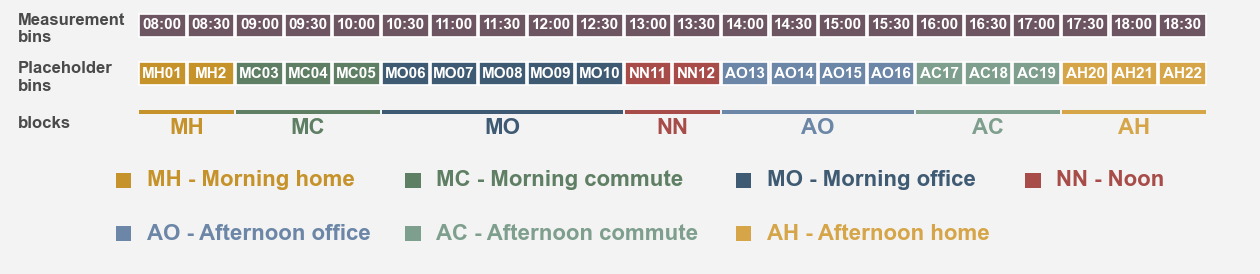

In [14]:
colors = {
    "MH": "#c6922a",
    "MC": "#5f7f64",
    "MO": "#3f5a73",
    "NN": "#a84c49",
    "AO": "#6b86a6",
    "AC": "#7f9f8e",
    "AH": "#d5a548"
}

smoke = "#4a4a4a"
bg = "#f3f3f3"

fig, ax = plt.subplots(figsize=(16, 3.3))
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.set_xlim(0, 24)
ax.set_ylim(0, 10)
ax.axis("off")

# ---------- helpers ----------
def add_box(x, y, w, h, color, text, txtcolor="white", fs=11):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor="white", linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            color=txtcolor, fontsize=fs, fontweight="bold")

def add_block(x, y, w, h, color, label):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor="none")
    ax.add_patch(rect)
    ax.text(x + w/2, y - 0.55, label, ha="center", va="center",   # increased gap
            fontsize=16, color=color, fontweight="bold")

def add_legend_item(x, y, color, text):
    # use scatter marker so it stays square visually
    ax.scatter(x, y, s=120, marker='s', color=color, edgecolors='none')
    
    ax.text(x + 0.45, y, text,
            va="center", ha="left",
            fontsize=16, color=color, fontweight="bold")

# ---------- labels (smaller fonts) ----------
ax.text(0.15, 9.25, "Measurement\nbins", ha="left", va="center",
        fontsize=12, color=smoke, fontweight="bold")
ax.text(0.15, 7.35, "Placeholder\nbins", ha="left", va="center",
        fontsize=12, color=smoke, fontweight="bold")
ax.text(0.15, 5.55, "blocks", ha="left", va="center",
        fontsize=12, color=smoke, fontweight="bold")

# ---------- measurement slots ----------
times = [
    "08:00","08:30","09:00","09:30","10:00","10:30","11:00","11:30",
    "12:00","12:30","13:00","13:30","14:00","14:30","15:00","15:30",
    "16:00","16:30","17:00","17:30","18:00","18:30"
]
top_color = "#6d5561"
x0, w, gap, y_top, h = 2.5, 0.9, 0.04, 8.95, 0.9

for i, t in enumerate(times):
    add_box(x0 + i*(w+gap), y_top, w, h, top_color, t, fs=11)

# ---------- placeholder slots ----------
slot_labels = [
    ("MH01","MH"), ("MH2","MH"),
    ("MC03","MC"), ("MC04","MC"), ("MC05","MC"),
    ("MO06","MO"), ("MO07","MO"), ("MO08","MO"), ("MO09","MO"), ("MO10","MO"),
    ("NN11","NN"), ("NN12","NN"),
    ("AO13","AO"), ("AO14","AO"), ("AO15","AO"), ("AO16","AO"),
    ("AC17","AC"), ("AC18","AC"), ("AC19","AC"),
    ("AH20","AH"), ("AH21","AH"), ("AH22","AH")
]

y_mid = 7.05
for i, (lab, grp) in enumerate(slot_labels):
    add_box(x0 + i*(w+gap), y_mid, w, h, colors[grp], lab, fs=11)

# ---------- blocks (thinner) ----------
groups = [("MH", 2), ("MC", 3), ("MO", 5), ("NN", 2), ("AO", 4), ("AC", 3), ("AH", 3)]
y_block = 5.9
block_h = 0.18   # thinner
start = x0

for grp, n in groups:
    width = n*w + (n-1)*gap
    add_block(start, y_block, width, block_h, colors[grp], grp)
    start += width + gap

# ---------- legend (NO frame) ----------
add_legend_item(2.2, 3.3, colors["MH"], "MH - Morning home")
add_legend_item(7.8, 3.3, colors["MC"], "MC - Morning commute")
add_legend_item(14.2, 3.3, colors["MO"], "MO - Morning office")
add_legend_item(19.8, 3.3, colors["NN"], "NN - Noon")

# ↓ push second row further down (more vertical spread)
add_legend_item(2.2, 1.2, colors["AO"], "AO - Afternoon office")
add_legend_item(7.8, 1.2, colors["AC"], "AC - Afternoon commute")
add_legend_item(14.2, 1.2, colors["AH"], "AH - Afternoon home")

plt.savefig(
    os.path.join(root_dir, "results", "plots", "placeholders_diagram.png"),
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.savefig(
    os.path.join(root_dir, "results", "plots", "placeholders_diagram.pdf"),
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

In [15]:
# Pivot table for `Photopic illuminance` and `melanopic EDI` values

metrics = [
    'Illuminance [lx] (CIE1931 2°)',
    'X v,mel,D65 (MEDI) [lx]' 
]

# Pivot table: one row per time, columns = date × metric
pivot_photopic_melanopic_trajectory_canada_df = copy_trajectory_canada_df.pivot_table(
    index='time',      # rows = time only
    columns='date',    # columns = dates
    values=metrics,    # metrics to pivot
    aggfunc='first'     # take the first value for each time/date (we have just one value for each timestamp)
).reset_index()

# Rename metrics
rename_map = {
    'Illuminance [lx] (CIE1931 2°)': 'Photopic illuminance (lx)',
    'X v,mel,D65 (MEDI) [lx]': 'Melanopic EDI (lx)'
}
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.rename(columns=rename_map, level=0)

# Replace NaNs with empty string
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.fillna("")
pivot_photopic_melanopic_trajectory_canada_df.to_csv(
    os.path.join(root_dir, "results", "tables", "pivot_photopic_melanopic_trajectory_canada.csv"),
    index=False
)
pivot_photopic_melanopic_trajectory_canada_df

time Photopic illuminance (lx)                        \
date                          2023-06-14 2023-06-16 2023-06-19   
0     08:00:00                      36.1       37.3       43.8   
1     08:30:00                     130.2      110.0      114.1   
2     09:00:00                    4553.4    15976.8     6286.0   
3     09:30:00                   15164.0    14620.2    11627.8   
4     09:45:00                    7540.7                         
5     10:00:00                   12543.8    14606.9    12254.8   
6     10:30:00                     464.6      154.2     3768.2   
7     11:00:00                     493.4      154.9     4047.0   
8     11:30:00                     421.9      155.9     4429.0   
9     12:00:00                     379.3      156.7     4311.8   
10    12:30:00                     359.1      156.2     3715.6   
11    13:00:00                    4904.2    15422.8    34813.6   
12    13:30:00                     639.1      941.1     1353.8   
13    14:00:00                     327.5      161.6     6518.5   
14    14:30:00                     279.3      165.1     7671.7   
15    15:00:00                     325.8      165.4     7671.2   
16    15:30:00                     251.5      165.8     8977.6   
17    16:00:00                    5845.9    12023.0     8389.2   
18    16:30:00                    8367.5    15424.6              
19    17:00:00                    1500.3     2813.6              
20    17:30:00                      63.8       27.0       31.4   
21    18:00:00                      37.2       33.4       61.8   
22    18:30:00                      35.9                         

     Melanopic EDI (lx)                        
date         2023-06-14 2023-06-16 2023-06-19  
0                  19.0       20.4       23.0  
1                  92.0       70.8       81.1  
2                4227.6    14421.8     6155.2  
3               14287.4    13535.0    10942.8  
4                7474.6                        
5               11539.1    13503.6    11466.1  
6                 355.0       93.2     3527.1  
7                 378.2       93.5     3858.5  
8                 320.2       93.9     4130.5  
9                 286.4       94.5     4171.3  
10                269.7       94.3     3421.9  
11               4439.6    14938.9    33750.6  
12                551.7      845.3     1185.9  
13                248.2       97.9     6252.4  
14                207.8       99.9     7325.8  
15                245.8      100.5     7678.2  
16                185.7      100.6     8660.9  
17               5553.3    10945.2     7783.4  
18               7709.9    14772.3             
19               1408.0     2715.7             
20                 47.1       22.2       24.2  
21                 18.4       24.4       46.3  
22                 17.5

In [16]:
# Pivot table for trajectory melanopic EDI values and two metadata entries ( scenes + lighting) 

metric_col = 'X v,mel,D65 (MEDI) [lx]'  # only this metric

# pivots
p_edi = copy_trajectory_canada_df.pivot_table(
    index="time", columns="date", values=metric_col, aggfunc="first"
)

p_scene = copy_trajectory_canada_df.pivot_table(
    index="time", columns="date", values="scene", aggfunc="first"
)

p_lighting = copy_trajectory_canada_df.pivot_table(
    index="time", columns="date", values="lighting", aggfunc="first"
)

# combine -> columns as (date, subheader)
out = pd.concat(
    {"Melanopic EDI (lx)": p_edi, "scene": p_scene, "lighting": p_lighting},
    axis=1
).swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

pivot_melanopic_with_metadata_df = out.reset_index().fillna("")
pivot_melanopic_with_metadata_df.to_csv(
    os.path.join(root_dir, "results", "tables", "pivot_melanopic_metadata_trajectory_canada.csv"),
    index=False
)


In [17]:
# Extract dates (first 8 characters: yyyymmdd)

trajectory_canada_dates = copy_trajectory_canada_df['date'].astype(str).unique().tolist()
trajectory_canada_dates

['2023-06-14', '2023-06-16', '2023-06-19']

In [18]:
# Create summary table for number of `Indoor` and `Outdoor` measurements 

grouped_df = copy_trajectory_canada_df.groupby(['date', 'view']).size().reset_index(name='count')

# Create a new column 'type' based on 'view'
grouped_df['index'] = grouped_df['view'].apply(lambda x: 'outdoor' if x == 'Outdoor' else 'indoor')

# Pivot the DataFrame to have 'Outdoor' and 'Indoor' as separate columns
pivot_summary_df = grouped_df.pivot_table(index='date', columns='index', values='count', aggfunc='sum', fill_value=0).reset_index()
# Add a 'Total' column to sum up counts for each date
pivot_summary_df['sum'] = pivot_summary_df[['indoor', 'outdoor']].sum(axis=1)

summary_row = {
    'date': 'total',
    'indoor': pivot_summary_df['indoor'].sum(),
    'outdoor': pivot_summary_df['outdoor'].sum(),
    'sum': pivot_summary_df['sum'].sum()
}
pivot_summary_df = pd.concat(
    [pivot_summary_df, pd.DataFrame([summary_row])],
    ignore_index=True
)
pivot_summary_df.index = pivot_summary_df.index + 1
pivot_summary_df.to_csv(
    os.path.join(root_dir, "results", "tables", "pivot_summary_trajectory_canada.csv"),
    index=False
)
pivot_summary_df

,date,indoor,outdoor,sum
1,2023-06-14,16,7,23
2,2023-06-16,14,7,21
3,2023-06-19,15,4,19
4,total,45,18,63


### Photopic illuminance

In [19]:
# Descriptive statistics ( Photopic illuminance)

# Group by time and compute mean, min, max, Q1, Q3, and IQR
photopic_stats = copy_trajectory_canada_df.groupby('time')['Illuminance [lx] (CIE1931 2°)'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
photopic_stats['iqr'] = photopic_stats['q3'] - photopic_stats['q1']

# Round mean to 2 decimals
photopic_stats['mean'] = photopic_stats['mean'].round(2)

# Reset index if needed
photopic_stats = photopic_stats.reset_index()
photopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,39.07,36.1,43.8,36.700,40.550,3.85
1,08:30:00,118.10,110.0,130.2,112.050,122.150,10.10
2,09:00:00,8938.73,4553.4,15976.8,5419.700,11131.400,5711.70
3,09:30:00,13804.00,11627.8,15164.0,13124.000,14892.100,1768.10
4,09:45:00,7540.70,7540.7,7540.7,7540.700,7540.700,0.00
5,10:00:00,13135.17,12254.8,14606.9,12399.300,13575.350,1176.05
6,10:30:00,1462.33,154.2,3768.2,309.400,2116.400,1807.00
7,11:00:00,1565.10,154.9,4047.0,324.150,2270.200,1946.05
8,11:30:00,1668.93,155.9,4429.0,288.900,2425.450,2136.55
9,12:00:00,1615.93,156.7,4311.8,268.000,2345.550,2077.55


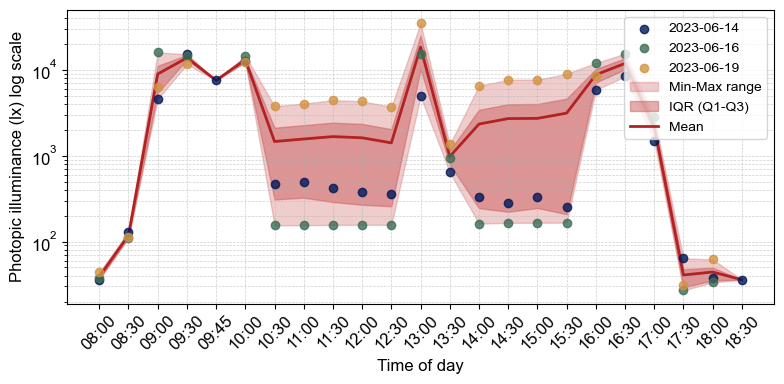

In [20]:
# Plot photopic illuminance throughout trajectory days

fig, ax = plt.subplots(figsize=(8,4))

scatter_handles = []  # to collect scatter handles for legend
colors = [cm.batlow(i/len(copy_trajectory_canada_df['date'].unique())) for i in range(len(copy_trajectory_canada_df['date'].unique()))]

# Plot each day's measurements as scatter
for i, date in enumerate(copy_trajectory_canada_df['date'].unique()):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df['date'] == date]
    sc = ax.scatter(
        [t.strftime('%H:%M') if not isinstance(t, str) else t[:5] for t in day_data['time']],
        day_data['Illuminance [lx] (CIE1931 2°)'],
        color=colors[i],
        alpha=0.8,
        zorder=4
    )
    scatter_handles.append((sc, str(date)))  # store handle + label

# Fill area between Q1 and Q3 (IQR)
iqr_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['q1'],
    photopic_stats['q3'],
    color='indianred',
    alpha=0.5,
    zorder=1,
    label='IQR (Q1-Q3)'
)

# Fill area between min and max
minmax_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['min'],
    photopic_stats['max'],
    color='indianred',
    alpha=0.3,
    zorder=0,
    label='Min-Max'
)

# Overlay mean lines
mean_line, = ax.plot(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['mean'],
    color='firebrick',
    linewidth=2,
    label='Mean',
    zorder=3
)

# Create legend: one handle per day + fill + mean
handles = [h for h, l in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels = [l for h, l in scatter_handles] + ['Min-Max range', 'IQR (Q1-Q3)', 'Mean']

ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)

# Log scale
ax.set_yscale('log')
# Labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('Photopic illuminance (lx) log scale')
#ax.set_title('Photopic illuminance per measurement day')
# Grid with minor lines
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.6, zorder=0)

# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()

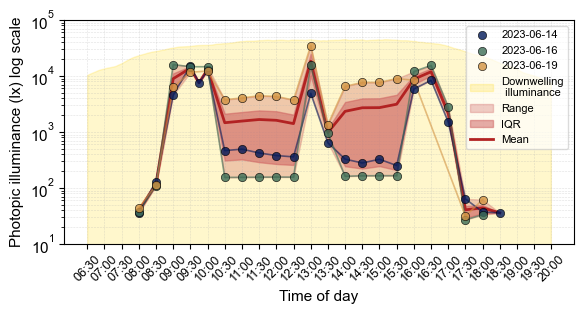

In [21]:
# Plot photopic illuminance throughout trajectory days + Downwelling illuminance (log scale)

fig, ax = plt.subplots(figsize=(6, 3.3))

# =========================================================
# ENVIRONMENTAL AVERAGE → Downwelling photopic illuminance
# =========================================================
smoothed_series = []
x_env = None

for df in (env_illuminance_14_df, env_illuminance_16_df, env_illuminance_19_df):
    d = df.copy()
    d["DateTime"] = pd.to_datetime(d["DateTime"])
    d = d.sort_values("DateTime")

    # restrict to 06:00–20:30
    d = d[
        (d["DateTime"].dt.time >= pd.to_datetime("06:30").time()) &
        (d["DateTime"].dt.time <= pd.to_datetime("20:00").time())
    ]

    x = d["DateTime"].dt.strftime("%H:%M")
    y = d["Out Ill (Lux)"].astype(float)

    y_smooth = y.rolling(window=100, center=True, min_periods=1).mean()
    smoothed_series.append(y_smooth.values)

    if x_env is None:
        x_env = x.values

# pointwise average
env_avg = np.mean(smoothed_series, axis=0)

downwelling_fill = ax.fill_between(
    x_env,
    1,                 # log-safe baseline
    env_avg,
    color="gold",
    alpha=0.2,
    zorder=0,
    label="Downwelling illuminance"
)

# =========================================================
# PHOTOPIC ILLUMINANCE
# =========================================================
scatter_handles = []
unique_dates = copy_trajectory_canada_df["date"].unique()
colors = [cm.batlow(i / len(unique_dates)) for i in range(len(unique_dates))]

for i, date in enumerate(unique_dates):
    day_data = copy_trajectory_canada_df[
        copy_trajectory_canada_df["date"] == date
    ]
    # ADD LINE
    ax.plot(
        [t.strftime("%H:%M") if not isinstance(t, str) else t[:5]
        for t in day_data["time"]],
        day_data["Illuminance [lx] (CIE1931 2°)"],
        color=colors[i],
        alpha=0.6,
        linewidth=1.2,
         zorder=6
    )
    sc = ax.scatter(
        [t.strftime("%H:%M") if not isinstance(t, str) else t[:5]
         for t in day_data["time"]],
        day_data["Illuminance [lx] (CIE1931 2°)"],
        color=colors[i],
        edgecolors="black",
        linewidth=0.5,
        alpha=0.8,
        zorder=7
    )
    scatter_handles.append((sc, str(date)))

# --- Min–Max ---
minmax_fill = ax.fill_between(
    [t.strftime("%H:%M") for t in photopic_stats["time"]],
    photopic_stats["min"],
    photopic_stats["max"],
    color="indianred",
    alpha=0.3,
    zorder=1,
    label="Range"
)

# --- IQR ---
iqr_fill = ax.fill_between(
    [t.strftime("%H:%M") for t in photopic_stats["time"]],
    photopic_stats["q1"],
    photopic_stats["q3"],
    color="indianred",
    alpha=0.5,
    zorder=2,
    label="IQR"
)

# --- Mean ---
mean_line, = ax.plot(
    [t.strftime("%H:%M") for t in photopic_stats["time"]],
    photopic_stats["mean"],
    color="firebrick",
    linewidth=2,
    zorder=5,
    label="Mean"
)

# =========================================================
# FORMATTING (30-min ticks)
# =========================================================

ax.set_xlabel("Time of day", fontsize=11)
# half-hour ticks
tick_times = pd.date_range("06:30", "20:00", freq="30min").strftime("%H:%M")
ax.set_xticks(tick_times)
plt.xticks(rotation=45, fontsize=9)

ax.set_yscale("log")
ax.set_ylabel("Photopic illuminance (lx) log scale", fontsize=11)
ax.set_ylim(1e1, 1e5)
plt.yticks( fontsize=11)


handles = (
    [h for h, _ in scatter_handles] +
    [downwelling_fill, minmax_fill, iqr_fill, mean_line]
)
labels = (
    [l for _, l in scatter_handles] +
    ["Downwelling\n illuminance", "Range", "IQR", "Mean"]
)

ax.legend(handles=handles, labels=labels, loc="upper right", fontsize=8, framealpha=0.7)

ax.grid(which="both", linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)

plt.tight_layout()
fig.savefig(
    os.path.join(root_dir, "results", "plots", "photopic_trajectory_days.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "photopic_trajectory_days.pdf"),
    dpi=300
)

### Melanopic EDI

In [22]:
# Descriptive statistics ( Melanopic EDI)

# Group by time and compute mean, min, max, Q1, Q3, and IQR
melanopic_stats = copy_trajectory_canada_df.groupby('time')['X v,mel,D65 (MEDI) [lx]'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
melanopic_stats['iqr'] = melanopic_stats['q3'] - melanopic_stats['q1']

# Round mean to 2 decimals
melanopic_stats['mean'] = melanopic_stats['mean'].round(2)

# Reset index if needed
melanopic_stats = melanopic_stats.reset_index()
melanopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,20.80,19.0,23.0,19.700,21.700,2.00
1,08:30:00,81.30,70.8,92.0,75.950,86.550,10.60
2,09:00:00,8268.20,4227.6,14421.8,5191.400,10288.500,5097.10
3,09:30:00,12921.73,10942.8,14287.4,12238.900,13911.200,1672.30
4,09:45:00,7474.60,7474.6,7474.6,7474.600,7474.600,0.00
5,10:00:00,12169.60,11466.1,13503.6,11502.600,12521.350,1018.75
6,10:30:00,1325.10,93.2,3527.1,224.100,1941.050,1716.95
7,11:00:00,1443.40,93.5,3858.5,235.850,2118.350,1882.50
8,11:30:00,1514.87,93.9,4130.5,207.050,2225.350,2018.30
9,12:00:00,1517.40,94.5,4171.3,190.450,2228.850,2038.40


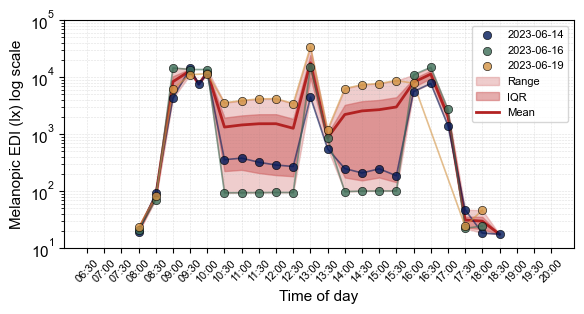

In [23]:
# Plot Melanopic EDI throughout trajectory days

fig, ax = plt.subplots(figsize=(6,3.3))

# --- helper: convert "time of day" to datetime on a dummy date ---
BASE_DATE = pd.Timestamp("2000-01-01")

def to_dt_timeofday(t):
    if isinstance(t, str):
        # expects "HH:MM..." strings
        return pd.to_datetime(f"{BASE_DATE.date()} {t[:5]}")
    # datetime.time / pandas Timestamp
    return pd.to_datetime(f"{BASE_DATE.date()} {t.strftime('%H:%M')}")

scatter_handles = []
unique_dates = copy_trajectory_canada_df["date"].unique()
colors = [cm.batlow(i / len(unique_dates)) for i in range(len(unique_dates))]

# =========================================================
# MELANOPIC EDI per day: line + scatter
# =========================================================
for i, date in enumerate(unique_dates):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df["date"] == date].copy()

    x_day = pd.to_datetime([to_dt_timeofday(t) for t in day_data["time"]])
    y_day = day_data["X v,mel,D65 (MEDI) [lx]"].astype(float).values

    # ensure time-sorted within day
    order = np.argsort(x_day.values)
    x_day = x_day[order]
    y_day = y_day[order]

    ax.plot(
        x_day, y_day,
        color=colors[i],
        alpha=0.6,
        linewidth=1.2,
        zorder=6
    )

    sc = ax.scatter(
        x_day, y_day,
        color=colors[i],
        edgecolors="black",
        linewidth=0.5,
        alpha=0.8,
        zorder=7
    )
    scatter_handles.append((sc, str(date)))

# =========================================================
# STATS: Range, IQR, Mean
# =========================================================
x_stats = pd.to_datetime([to_dt_timeofday(t) for t in melanopic_stats["time"]])

minmax_fill = ax.fill_between(
    x_stats,
    melanopic_stats["min"].astype(float),
    melanopic_stats["max"].astype(float),
    color="indianred",
    alpha=0.3,
    zorder=1,
    label="Range"
)

iqr_fill = ax.fill_between(
    x_stats,
    melanopic_stats["q1"].astype(float),
    melanopic_stats["q3"].astype(float),
    color="indianred",
    alpha=0.5,
    zorder=2,
    label="IQR"
)

mean_line, = ax.plot(
    x_stats,
    melanopic_stats["mean"].astype(float),
    color="firebrick",
    linewidth=2,
    zorder=5,
    label="Mean"
)

# =========================================================
# AXIS FORMATTING: 06:30–20:00, ticks every 30 min
# =========================================================
ax.set_yscale("log")
ax.set_ylim(1e1, 1e5)
plt.yticks(fontsize=11)
ax.set_ylabel("Melanopic EDI (lx) log scale", fontsize=11)

ax.set_xlabel("Time of day", fontsize=11)
xmin = BASE_DATE + pd.Timedelta(hours=5, minutes=50)   #  padding before
xmax = BASE_DATE + pd.Timedelta(hours=20, minutes=40) #  padding after
ax.set_xlim(xmin, xmax)

# half-hour ticks + HH:MM labels
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45, fontsize=8)
tick_times = pd.date_range("2000-01-01 06:30", "2000-01-01 20:00", freq="30min")
ax.set_xticks(tick_times)

# legend
handles = [h for h, _ in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels  = [l for _, l in scatter_handles] + ["Range", "IQR", "Mean"]
ax.legend(handles=handles, labels=labels, loc="upper right", fontsize=8)


# y-grid only (drops x-grid)
ax.grid(which="both", linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)

plt.tight_layout()
fig.savefig(
    os.path.join(root_dir, "results", "plots", "melanopic_trajectory_days.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "melanopic_trajectory_days.pdf"),
    dpi=300
)

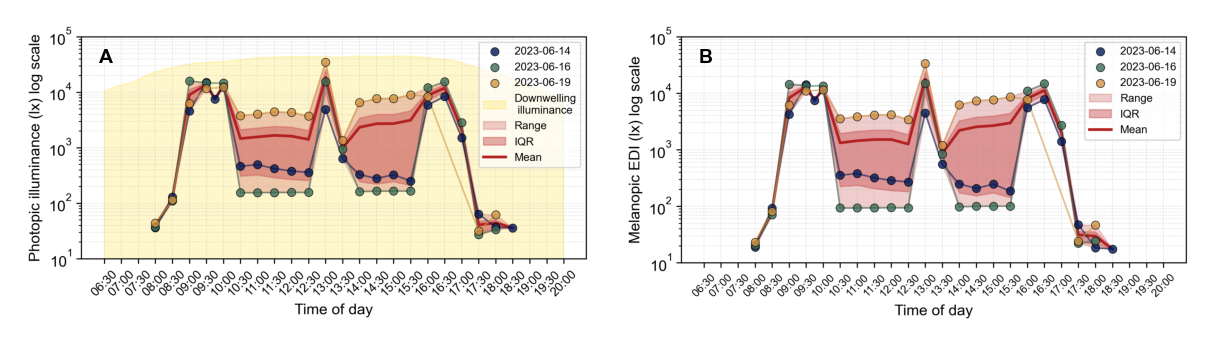

In [24]:
# Figure Photopic, melanopic
# paths
p1 = os.path.join(root_dir, "results", "plots", "photopic_trajectory_days.png")
p2 = os.path.join(root_dir, "results", "plots", "melanopic_trajectory_days.png")

# read images
im1 = Image.open(p1)
im2 = Image.open(p2)

# figure
fig, axs = plt.subplots(1, 2, figsize=(12, 3.3))

axs[0].imshow(im1)
axs[1].imshow(im2)

for ax in axs:
    ax.axis("off")

# panel labels
axs[0].text(
    0.15, 0.88, "A",
    transform=axs[0].transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

axs[1].text(
    0.15, 0.88, "B",
    transform=axs[1].transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

plt.tight_layout(pad=0.1, w_pad=0.2)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_photopic_melanopic.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_photopic_melanopic.pdf"),
    dpi=300
)

In [25]:
dt = 0.5     # 30 min

summary_df = (
    copy_trajectory_canada_df
    .groupby("date")["X v,mel,D65 (MEDI) [lx]"]
    .apply(lambda v: pd.Series({
        "dose_lx": np.sum(v * dt),
        "time_above_250": np.sum(v > 250) * dt,
        "time_above_1000": np.sum(v > 1000) * dt,
        "time_above_10000": np.sum(v > 10000) * dt
    }))
    .unstack()
)

summary_df = summary_df.drop(index="mean", errors="ignore")

summary_df.loc["mean"] = summary_df.mean(axis=0)

summary_df = summary_df.round(1)
summary_df 


,dose_lx,time_above_250,time_above_1000,time_above_10000
date,,,,
2023-06-14,29941.1,7.0,4.0,1.0
2023-06-16,43342.0,4.0,3.5,3.0
2023-06-19,60242.6,7.5,7.5,1.5
mean,44508.5,6.2,5.0,1.8


## Trajectory models, synthetic sequences


In [26]:
# Define the trajectory bins as placeholders for the synthetic days (22 time slots)

placeholders = ['MH01', 'MH02', 'MC03', 'MC04', 'MC05', 'MO06', 'MO07', 'MO08', 'MO09', 'MO10', 'NN11', 'NN12', 'AO13', 'AO14', 'AO15', 'AO16', 'AC17', 'AC18', 'AC19', 'AH20', 'AH21', 'AH22']
len(placeholders)

22

In [27]:
# Generate 22 timeslot labels (08:00, 18:30) correspond to 22 placeholders

times = [f"{h:02d}:{m:02d}" for h, m in
     [(8,0),(8,30),(9,0),(9,30),(10,0),(10,30),(11,0),(11,30),
     (12,0),(12,30),(13,0),(13,30),(14,0),(14,30),(15,0),(15,30),
     (16,0),(16,30),(17,0),(17,30),(18,0),(18,30)]]


### Naive model

In [28]:
# 100000 sequence, random sampling with permutation of 63 melanopic EDI values in 22 placeholders. 

np.random.seed(20)
n_sequences = 100000  # number of synthetic sequences
n_slots = len(placeholders)
melanopic_values = copy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].dropna().values
# Generate all sequences at once
naive_sequences = np.array([np.random.choice(melanopic_values, size=n_slots) 
                          for _ in range(n_sequences)]).T 

# Create DataFrame in one shot
naive_synthetic_df = pd.DataFrame(naive_sequences, index=placeholders,
                            columns=[f'seq_{i+1:04d}' for i in range(n_sequences)])

# synthetic_df now has placeholders as index and sequences as columns
print(naive_synthetic_df.shape)
naive_synthetic_df.iloc[:, :10].head()

naive_synthetic_df.to_csv(
    os.path.join(root_dir, "results", "tables", "sequences", "naive_melanopic_sequence.csv")
)


(22, 100000)


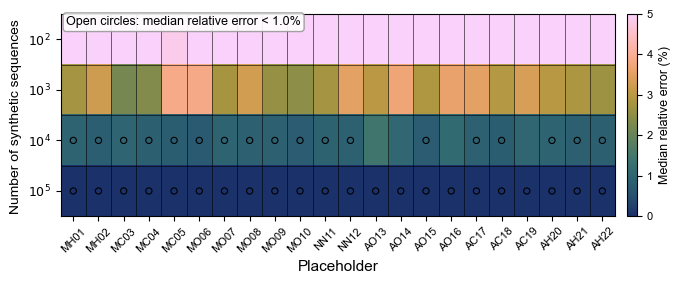

In [29]:
# Plot heatmap of median reletive error heatmap (monte carlo convergence) for Naive model

median_err, all_err = plot_monte_carlo_stability_heatmap(
    naive_sequences,
    rel_threshold=0.01,
    sequences_name="naive_model",
    placeholders=placeholders,
    save_dir=os.path.join(root_dir, "results", "plots"),
    dpi=300
)

### Naive indoor model

In [30]:
# 100000 sequence, random sampling with permutation of 20 melanopic-EDI values in 22 placeholders.
np.random.seed(20)
# Number of synthetic sequences
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
indoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Indoor', na=False)]

# 2. Extract melanopic values from indoor data only
indoor_melanopic = indoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
naive_indoor_sequences = np.array([
    np.random.choice(indoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
indoor_synthetic_df = pd.DataFrame(
    naive_indoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(indoor_synthetic_df.shape)
indoor_synthetic_df.iloc[:, :10].head()

indoor_synthetic_df.to_csv(
    os.path.join(root_dir, "results", "tables", "sequences", "naive_indoor_melanopic_sequence.csv")
)

(22, 100000)


### Naive outdoor model

In [31]:
# 100000 sequence, random sampling with permutation of 43 melanopic-EDI values in 22 placeholders.
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
outdoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Outdoor', na=False)]

# 2. Extract melanopic values from indoor data only
outdoor_melanopic = outdoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
naive_outdoor_sequences = np.array([
    np.random.choice(outdoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
outdoor_synthetic_df = pd.DataFrame(
    naive_outdoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(outdoor_synthetic_df.shape)
outdoor_synthetic_df.iloc[:, :10].head()

outdoor_synthetic_df.to_csv(
    os.path.join(root_dir, "results", "tables", "sequences", "naive_outdoor_melanopic_sequence.csv")
)

(22, 100000)


### Time restricted model

In [32]:
df = copy_trajectory_canada_df.copy()
df['datetime'] = pd.to_datetime(df['datetime'])  

# create 22 fixed half-hour bin starts from 07:59 for mid measured day
bin_starts = pd.date_range("2023-06-16 07:59", periods=22, freq="30min").time

# collect values per bin (no new df columns)
mel_bins = []
for start in bin_starts:
    end = (pd.Timestamp("2000-01-01 " + start.strftime("%H:%M")) + pd.Timedelta(minutes=30)).time()
    mask = (df['datetime'].dt.time >= start) & (df['datetime'].dt.time < end)
    vals = df.loc[mask, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    mel_bins.append(vals)

In [33]:
n_sequences = 100000
n_slots = len(mel_bins)   # should be 22

# Generate sequences: one random value from bin i → placeholder i
time_restricted_sequences = np.zeros((n_slots, n_sequences))

for i, bin_values in enumerate(mel_bins):
    bin_values = np.array(bin_values)
    if len(bin_values) == 0:
        raise ValueError(f"Bin {i} is empty. Cannot sample.")
    time_restricted_sequences[i] = np.random.choice(bin_values, size=n_sequences, replace=True)

# Create DataFrame
time_restricted_df = pd.DataFrame(
    time_restricted_sequences,
    index=placeholders, 
    columns=[f"seq_{i+1:04d}" for i in range(n_sequences)]
)
print(time_restricted_df.shape)
time_restricted_df.iloc[:, :10].head()

time_restricted_df.to_csv(
    os.path.join(root_dir, "results", "tables", "sequences", "time_restricted_melanopic_sequence.csv")
)

(22, 100000)


### Location restricted model

In [34]:

# Extract hour + minute as float for easier comparison
df['hour_min'] = df['datetime'].dt.hour * 100 + df['datetime'].dt.minute

# Create empty column for placeholder group
df['location_group'] = ''

# Morning (before 12.99 ~ 12:59)
morning_mask = df['hour_min'] <= 1259
afternoon_mask = df['hour_min'] >= 1359
noon_mask = (df['hour_min'] > 1259) & (df['hour_min'] < 1359)

# Morning placeholders
df.loc[morning_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'MH'  # Morning Home
df.loc[morning_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'MO'  # Morning Office
df.loc[morning_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'MC'  # Morning Commute

# Afternoon placeholders
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'AH'  # Afternoon Home
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'AO'  # Afternoon Office
df.loc[afternoon_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'AC'  # Afternoon Commute

# Noon placeholders
df.loc[noon_mask, 'location_group'] = 'NN'  # Noon

In [35]:
# Extract melanopic values per activity category
group_to_values = {}

for g in ['MH','MO','MC','AH','AO','AC','NN']:
    vals = df.loc[df['location_group'] == g, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    group_to_values[g] = vals.astype(float)
# Merge categories based on your mapping
location_map = {
    'H': ['MH', 'AH'],    # Home
    'O': ['MO', 'AO'],    # Office
    'C': ['MC', 'AC'],    # Commute
    'N': ['NN']           # Noon
}
# Build final pools
location_pool = {}
for key, groups in location_map.items():
    merged = np.concatenate([group_to_values[g] for g in groups if len(group_to_values[g]) > 0])
    location_pool[key] = merged

In [36]:
n_sequences = 100000  # number of synthetic sequences
outfile = os.path.join(
    root_dir, "results", "tables", "sequences", "location_restricted_melanopic_sequence.csv"
)
# Map each placeholder to its activity type (second character)
placeholder_location = []
for ph in placeholders:
    if ph[:2] == 'NN':  # noon placeholders
        placeholder_location.append('N')
    else:
        placeholder_location.append(ph[1])  # H, O, C

# Initialize matrix
location_restricted_sequences = np.zeros((len(placeholders), n_sequences))

# Fill each placeholder row from the merged activity pool
for i, loc in enumerate(placeholder_location):
    pool = location_pool[loc]  # H, O, C, or N
    location_restricted_sequences[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame
location_restricted_df = pd.DataFrame(location_restricted_sequences, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save CSV
location_restricted_df.to_csv(outfile)
print("Done.")

Done.


### Time/location restricted model

In [37]:
# All time-activity groups in your labeling scheme
codes = ['MH','MO','MC','AH','AO','AC','NN']

time_location_pool = {}
for code in codes:
    vals = df.loc[df['location_group'] == code,
                  'X v,mel,D65 (MEDI) [lx]'].dropna().values
    time_location_pool[code] = vals.astype(float)


In [38]:
n_sequences = 100000
chunk_size = 1000
outfile = os.path.join(
    root_dir, "results", "tables", "sequences", "time_location_restricted_melanopic_sequence.csv"
)

# Each placeholder draws from its exact pool (AO → AO, MH → MH, etc.)
time_location_restricted_sequences = np.zeros((len(placeholders), n_sequences))

for i, ph in enumerate(placeholders):
    pool = time_location_pool[ph[:2]]  # first two letters = time + activity
    time_location_restricted_sequences[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame: rows = placeholders, columns = sequences
time_location_restricted_df = pd.DataFrame(time_location_restricted_sequences, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save to CSV
time_location_restricted_df .to_csv(outfile)
print("Done.")

Done.


### Tailored model

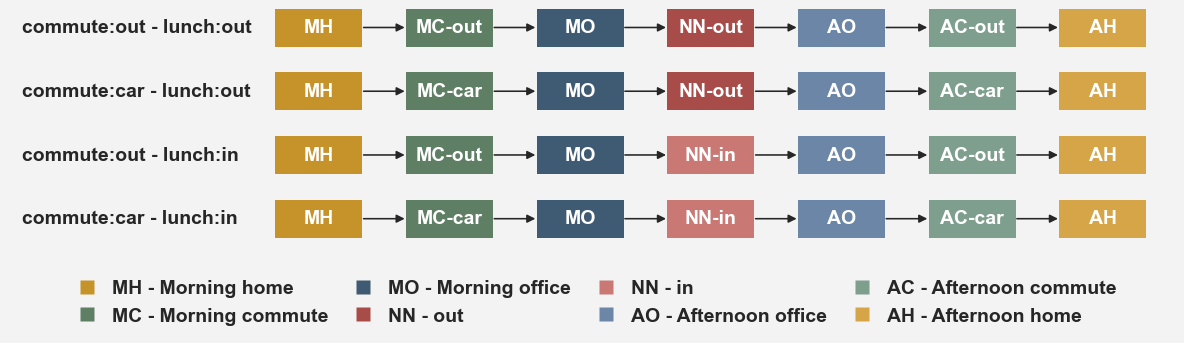

In [39]:
colors = {
    "MH": "#c6922a",
    "MC": "#5f7f64",
    "MO": "#3f5a73",
    "NN_out": "#a84c49",
    "NN_in": "#c97874",
    "AO": "#6b86a6",
    "AC": "#7f9f8e",
    "AH": "#d5a548"
}

smoke = "#262626"
bg = "#f3f3f3"

fig, ax = plt.subplots(figsize=(12, 3))
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)


ax.set_xlim(-1.8, 12.9)
ax.set_ylim(1.78, 4.35)
ax.axis("off")

node_w, node_h = 1.10, 0.42

def draw_node(x, y, label, color):
    rect = Rectangle(
        (x - node_w / 2, y - node_h / 2),
        node_w, node_h,
        linewidth=0,
        edgecolor="none",
        facecolor=color
    )
    ax.add_patch(rect)
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        color="white"
    )

def draw_edge(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2 - node_w / 2 + 0.02, y2),
        xytext=(x1 + node_w / 2 - 0.02, y1),
        arrowprops=dict(arrowstyle="-|>", lw=1.15, color=smoke)
    )

xs = [2.1, 3.75, 5.40, 7.05, 8.70, 10.35, 12.0]
ys = [4.15, 3.45, 2.75, 2.05]

scenarios = [
    ["MH", "MC-out", "MO", "NN-out", "AO", "AC-out", "AH"],
    ["MH", "MC-car", "MO", "NN-out", "AO", "AC-car", "AH"],
    ["MH", "MC-out", "MO", "NN-in",  "AO", "AC-out", "AH"],
    ["MH", "MC-car", "MO", "NN-in",  "AO", "AC-car", "AH"]
]

row_labels = [
    "commute:out - lunch:out",
    "commute:car - lunch:out",
    "commute:out - lunch:in",
    "commute:car - lunch:in"
]

def color_for(label):
    if label == "MH": return colors["MH"]
    if label.startswith("MC"): return colors["MC"]
    if label == "MO": return colors["MO"]
    if label == "NN-out": return colors["NN_out"]
    if label == "NN-in": return colors["NN_in"]
    if label == "AO": return colors["AO"]
    if label.startswith("AC"): return colors["AC"]
    if label == "AH": return colors["AH"]

for y, row, row_lab in zip(ys, scenarios, row_labels):
    for i, (x, label) in enumerate(zip(xs, row)):
        draw_node(x, y, label, color_for(label))
        if i < len(xs) - 1:
            draw_edge(xs[i], y, xs[i + 1], y)

    # LEFT SIDE SCENARIO LABEL
    ax.text(
        -1.65, y, row_lab,
        ha="left", va="center",
        fontsize=14, fontweight="bold",
        color=smoke
    )

legend_handles = [
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["MH"], markeredgecolor='none',
           label='MH - Morning home'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["MC"], markeredgecolor='none',
           label='MC - Morning commute'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["MO"], markeredgecolor='none',
           label='MO - Morning office'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["NN_out"], markeredgecolor='none',
           label='NN - out'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["NN_in"], markeredgecolor='none',
           label='NN - in'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["AO"], markeredgecolor='none',
           label='AO - Afternoon office'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["AC"], markeredgecolor='none',
           label='AC - Afternoon commute'),
    Line2D([0], [0], marker='s', linestyle='None', markersize=10,
           markerfacecolor=colors["AH"], markeredgecolor='none',
           label='AH - Afternoon home')
]

leg = ax.legend(
    handles=legend_handles,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),  
    frameon=False,
    fontsize=14,
    handletextpad=0.28,
    columnspacing=0.8
)

for txt in leg.get_texts():
    txt.set_color(smoke)
    txt.set_fontweight("bold")

# tighter global margins
fig.subplots_adjust(left=0.02, right=0.99, top=0.98, bottom=0.2)

plt.savefig(
    os.path.join(root_dir, "results", "plots", "tailored_model.png"),
    dpi=600,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(root_dir, "results", "plots", "tailored_model.pdf"),
    dpi=600,
    bbox_inches="tight"
)

In [40]:
tailored_trajectory_sequences = pd.read_excel(
    os.path.join(root_dir, "data", "tailored_trajectory_sequences.xlsx"),
    header=1
)
tailored_trajectory_sequences

,time,Unnamed: 1,14_commute_car_lunch_out,Unnamed: 3,14_commute_out_lunch_out,Unnamed: 5,14_commute_out_lunch_in,Unnamed: 7,14_commute_car_lunch_in,Unnamed: 9,16_commute_car_lunch_out,Unnamed: 11,16_commute_out_lunch_out,Unnamed: 13,16_commute_out_lunch_in,Unnamed: 15,16_commute_car_lunch_in,Unnamed: 17,19_commute_car_lunch_out,Unnamed: 19,19_commute_out_lunch_out,Unnamed: 21,19_commute_out_lunch_in,Unnamed: 23,19_commute_car_lunch_in
0,08:00:00,home,19.0,home,19.0,home,19.0,home,19.0,home,20.4,home,20.4,home,20.4,home,20.4,home,23.0,home,23.0,home,23.0,home,23.0
1,08:30:00,home,92.0,home,92.0,home,92.0,home,92.0,home,70.8,home,70.8,home,70.8,home,70.8,home,81.1,home,81.1,home,81.1,home,81.1
2,09:00:00,car,6813.4,outdoor,4227.6,outdoor,4227.6,car,6813.4,car,6813.4,outdoor,14421.8,outdoor,14421.8,car,6813.4,car,6813.4,outdoor,6155.2,outdoor,6155.2,car,6813.4
3,09:30:00,car,6813.4,outdoor,14287.4,outdoor,14287.4,car,6813.4,car,6813.4,outdoor,13535.0,outdoor,13535.0,car,6813.4,car,6813.4,outdoor,10942.8,outdoor,10942.8,car,6813.4
4,10:00:00,car,6813.4,outdoor,11539.1,outdoor,11539.1,car,6813.4,car,6813.4,outdoor,13503.6,outdoor,13503.6,car,6813.4,car,6813.4,outdoor,11466.1,outdoor,11466.1,car,6813.4
5,10:30:00,office,355.0,office,355.0,office,355.0,office,355.0,office,93.2,office,93.2,office,93.2,office,93.2,office,3527.1,office,3527.1,office,3527.1,office,3527.1
6,11:00:00,office,378.2,office,378.2,office,378.2,office,378.2,office,93.5,office,93.5,office,93.5,office,93.5,office,3858.5,office,3858.5,office,3858.5,office,3858.5
7,11:30:00,office,320.2,office,320.2,office,320.2,office,320.2,office,93.9,office,93.9,office,93.9,office,93.9,office,4130.5,office,4130.5,office,4130.5,office,4130.5
8,12:00:00,office,286.4,office,286.4,office,286.4,office,286.4,office,94.5,office,94.5,office,94.5,office,94.5,office,4171.3,office,4171.3,office,4171.3,office,4171.3
9,12:30:00,office,269.7,office,269.7,office,269.7,office,269.7,office,94.3,office,94.3,office,94.3,office,94.3,office,3421.9,office,3421.9,office,3421.9,office,3421.9


In [41]:
# Calculating summary metrics for tailored sequences

values = tailored_trajectory_sequences["14_commute_car_lunch_out"].dropna().values
dt = 0.5  # 30 min

rows = []

for col in tailored_trajectory_sequences.select_dtypes(include="number").columns:
    values = tailored_trajectory_sequences[col].dropna().values
    
    rows.append({
        "sequence": col,
        "Dose (lx.h)": np.sum(values * dt),
        "TAT>250 lx (h)": np.sum(values > 250) * dt,
        "TAT>1000 lx (h)": np.sum(values > 1000) * dt,
        "TAT>10000 lx (h)": np.sum(values > 10000) * dt
    })

metrics_df = pd.DataFrame(rows)
metrics_df.reset_index(drop=True)

metrics_df

,sequence,Dose (lx.h),TAT>250 lx (h),TAT>1000 lx (h),TAT>10000 lx (h)
0,14_commute_car_lunch_out,26225.30,6.5,4.0,0.0
1,14_commute_out_lunch_out,28147.75,6.5,4.0,1.0
2,14_commute_out_lunch_in,24259.85,6.5,3.0,1.0
3,14_commute_car_lunch_in,22337.40,6.5,3.0,0.0
4,16_commute_car_lunch_out,35894.35,4.0,4.0,1.0
5,16_commute_out_lunch_out,50400.95,4.0,4.0,3.5
6,16_commute_out_lunch_in,36307.35,4.0,3.0,2.5
7,16_commute_car_lunch_in,21800.75,4.0,3.0,0.0
8,19_commute_car_lunch_out,78814.55,8.5,8.5,1.0
9,19_commute_out_lunch_out,84331.50,8.5,8.5,2.0


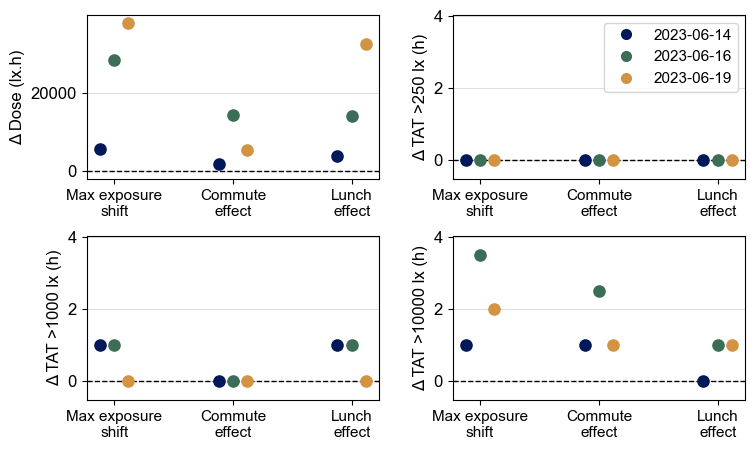

In [42]:
# Effect plots for summary metrics
df = metrics_df.copy()

df["day"] = df["sequence"].str.split("_").str[0]
df["scenario"] = df["sequence"].str.replace(r"^\d+_", "", regex=True)

days = ["14", "16", "19"]

date_map = {
    "14": "2023-06-14",
    "16": "2023-06-16",
    "19": "2023-06-19",
}

colors_list = [
    cm.batlow(i / len(days))
    for i in range(len(days))
]

colors = dict(zip(days, colors_list))

metrics = {
    "Dose (lx.h)": "Δ Dose (lx.h)",
    "TAT>250 lx (h)": "Δ TAT >250 lx (h)",
    "TAT>1000 lx (h)": "Δ TAT >1000 lx (h)",
    "TAT>10000 lx (h)": "Δ TAT >10000 lx (h)",
}

contrast_order = [
    "Max exposure\nshift",
    "Commute\neffect",
    "Lunch\neffect",
]

def compute_contrasts(metric):
    rows = []

    for day in days:
        d = df[df["day"] == day].set_index("scenario")

        max_shift = (
            d.loc["commute_out_lunch_out", metric]
            - d.loc["commute_car_lunch_in", metric]
        )

        commute_effect = (
            (
                d.loc["commute_out_lunch_out", metric]
                - d.loc["commute_car_lunch_out", metric]
            )
            +
            (
                d.loc["commute_out_lunch_in", metric]
                - d.loc["commute_car_lunch_in", metric]
            )
        ) / 2

        lunch_effect = (
            (
                d.loc["commute_out_lunch_out", metric]
                - d.loc["commute_out_lunch_in", metric]
            )
            +
            (
                d.loc["commute_car_lunch_out", metric]
                - d.loc["commute_car_lunch_in", metric]
            )
        ) / 2

        rows.append({
            "day": day,
            "Max exposure\nshift": max_shift,
            "Commute\neffect": commute_effect,
            "Lunch\neffect": lunch_effect,
        })

    return pd.DataFrame(rows)

effects = {metric: compute_contrasts(metric) for metric in metrics}

x = np.arange(len(contrast_order))
offsets = [-0.12, 0.00, 0.12]

fig, axes = plt.subplots(2, 2, figsize=(8.5, 5))
axes = axes.flatten()

plt.subplots_adjust(wspace=0.25, hspace=0.35)

tat_values = []
for metric in ["TAT>250 lx (h)", "TAT>1000 lx (h)", "TAT>10000 lx (h)"]:
    tat_values.extend(effects[metric][contrast_order].to_numpy().flatten())

tat_min = min(0, min(tat_values))
tat_max = max(tat_values)
tat_pad = (tat_max - tat_min) * 0.15 if tat_max > tat_min else 1
tat_ylim = (tat_min - tat_pad, tat_max + tat_pad)

for ax, (metric, ylabel) in zip(axes, metrics.items()):
    eff = effects[metric]

    for i, day in enumerate(days):
        y = eff.loc[eff["day"] == day, contrast_order].values.flatten()

        ax.scatter(
            x + offsets[i],
            y,
            s=65,
            color=colors[day],
            zorder=3
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(contrast_order, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.4)

    if metric != "Dose (lx.h)":
        ax.set_ylim(tat_ylim)

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=colors[day],
        label=date_map[day],
        markersize=7
    )
    for day in days
]

fig.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.88),
    fontsize=11,
    frameon=True
)

plt.savefig(
    os.path.join(root_dir, "results", "plots", "tailored_model_effect_plot.png"),
    dpi=600,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(root_dir, "results", "plots", "tailored_model_effect_plot.pdf"),
    dpi=600,
    bbox_inches="tight"
)

In [43]:
metrics = [
    "Dose (lx.h)",
    "TAT>250 lx (h)",
    "TAT>1000 lx (h)",
    "TAT>10000 lx (h)",
]

def compute_contrasts(metric):
    rows = []

    for day in days:
        d = df[df["day"] == day].set_index("scenario")

        rows.append({
            "day": day,
            "Max exposure shift":
                d.loc["commute_out_lunch_out", metric] -
                d.loc["commute_car_lunch_in", metric],

            "Commute effect":
                (
                    (d.loc["commute_out_lunch_out", metric] -
                     d.loc["commute_car_lunch_out", metric]) +
                    (d.loc["commute_out_lunch_in", metric] -
                     d.loc["commute_car_lunch_in", metric])
                ) / 2,

            "Lunch effect":
                (
                    (d.loc["commute_out_lunch_out", metric] -
                     d.loc["commute_out_lunch_in", metric]) +
                    (d.loc["commute_car_lunch_out", metric] -
                     d.loc["commute_car_lunch_in", metric])
                ) / 2,
        })

    return pd.DataFrame(rows)

summary_rows = []

for metric in metrics:
    eff = compute_contrasts(metric)

    for contrast in ["Max exposure shift", "Commute effect", "Lunch effect"]:
        values = eff[contrast].values

        summary_rows.append({
            "Metric": metric,
            "Contrast": contrast,
            "Median Δ": np.median(values),
            "Min Δ": np.min(values),
            "Max Δ": np.max(values),
            "Positive days": f"{np.sum(values > 0)}/{len(values)}",
        })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Metric,Contrast,Median Δ,Min Δ,Max Δ,Positive days
0,Dose (lx.h),Max exposure shift,28600.2,5810.35,38082.65,3/3
1,Dose (lx.h),Commute effect,5517.2,1922.45,14506.60,3/3
2,Dose (lx.h),Lunch effect,14093.6,3887.90,32565.45,3/3
3,TAT>250 lx (h),Max exposure shift,0.0,0.00,0.00,0/3
4,TAT>250 lx (h),Commute effect,0.0,0.00,0.00,0/3
5,TAT>250 lx (h),Lunch effect,0.0,0.00,0.00,0/3
6,TAT>1000 lx (h),Max exposure shift,1.0,0.00,1.00,2/3
7,TAT>1000 lx (h),Commute effect,0.0,0.00,0.00,0/3
8,TAT>1000 lx (h),Lunch effect,1.0,0.00,1.00,2/3
9,TAT>10000 lx (h),Max exposure shift,2.0,1.00,3.50,3/3


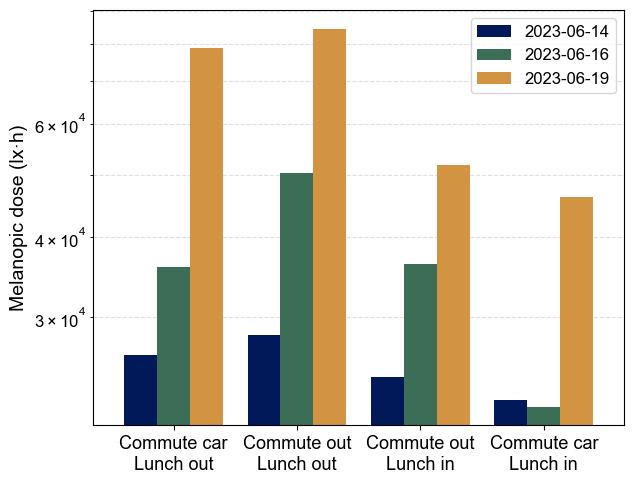

In [44]:
# Prepare data
plot_df = metrics_df.copy()
plot_df["day"] = plot_df["sequence"].str.split("_").str[0]
plot_df["scenario"] = plot_df["sequence"].str.replace(r"^\d+_", "", regex=True)

label_map = {
    "commute_car_lunch_out": "Commute car\nLunch out",
    "commute_out_lunch_out": "Commute out\nLunch out",
    "commute_out_lunch_in": "Commute out\nLunch in",
    "commute_car_lunch_in": "Commute car\nLunch in",
}

scenario_order = [
    "Commute car\nLunch out",
    "Commute out\nLunch out",
    "Commute out\nLunch in",
    "Commute car\nLunch in",
]

plot_df["scenario"] = plot_df["scenario"].map(label_map)
plot_df["scenario"] = pd.Categorical(
    plot_df["scenario"],
    categories=scenario_order,
    ordered=True
)

# Pivot for grouped bar plot
pivot_df = (
    plot_df
    .pivot(index="scenario", columns="day", values="Dose (lx.h)")
    .sort_index()
)

# Colors
days = ["14", "16", "19"]
date_map = {
    "14": "2023-06-14",
    "16": "2023-06-16",
    "19": "2023-06-19",
}
colors = [cm.batlow(i / len(days)) for i in range(len(days))]

# Plot
fig, ax = plt.subplots(figsize=(6.5, 5))

pivot_df[days].plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.8,
)

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Melanopic dose (lx·h)", fontsize=14)
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(True, axis="y", which="both",  linestyle="--", alpha=0.4)
ax.tick_params(axis="x", rotation=0, labelsize=13)

# Legend inside plot box
ax.legend(
    labels=[date_map[d] for d in days],
    loc="upper right",
    fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(root_dir, "results", "plots", "tailored_model_dose_plot.png"),
    dpi=600,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(root_dir, "results", "plots", "tailored_model_dose_plot.pdf"),
    dpi=600,
    bbox_inches="tight"
)


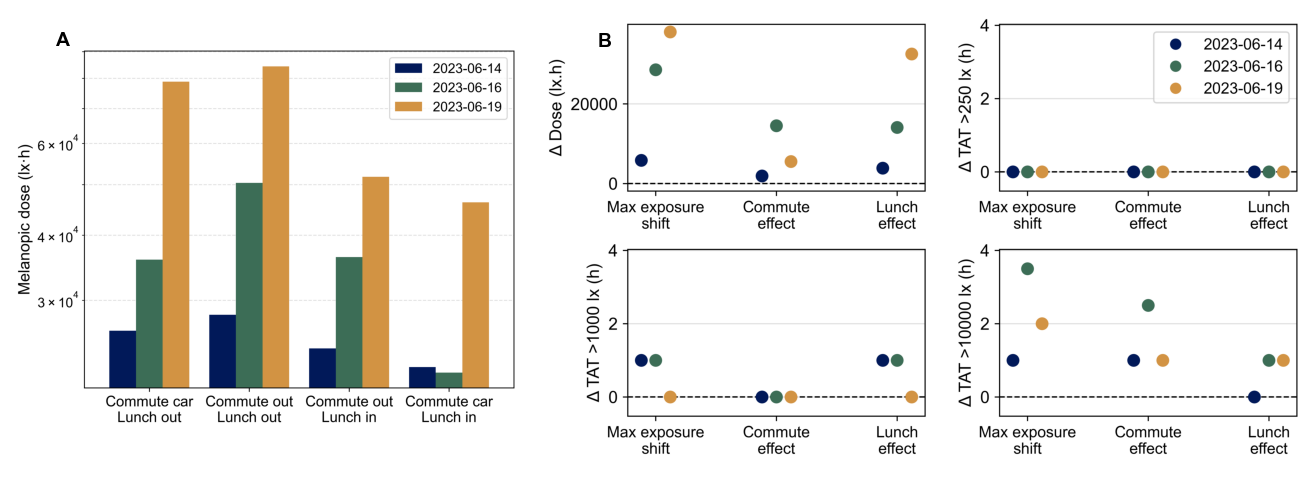

In [45]:
# paths
p1 = os.path.join(root_dir, "results", "plots", "tailored_model_dose_plot.png")
p2 = os.path.join(root_dir, "results", "plots", "tailored_model_effect_plot.png")

# read images
im1 = Image.open(p1)
im2 = Image.open(p2)

# figure
fig, axs = plt.subplots(
    1, 2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [2, 3]}
)

axs[0].imshow(im1)
axs[1].imshow(im2)

for ax in axs:
    ax.axis("off")

# panel labels
axs[0].text(0.09, 1.03, "A", transform=axs[0].transAxes,
            ha="left", va="top", fontsize=14, fontweight="bold")

axs[1].text(0.077, 0.95, "B", transform=axs[1].transAxes,
            ha="left", va="top", fontsize=14, fontweight="bold")

plt.tight_layout(pad=0.1, w_pad=1)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_tailored_analysis.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_tailored_analysis.pdf"),
    dpi=300
)

In [46]:
plt.tight_layout(pad=0.1, w_pad=0.2)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_photopic_melanopic.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_photopic_melanopic.pdf"),
    dpi=300
)

<Figure size 640x480 with 0 Axes>

### Plot synthetic model distributions

In [47]:
model_order = [
    "naive",
    "naive_indoor",
    "naive_outdoor",
    "time_restricted",
    "location_restricted",
    "time_location_restricted",
]

In [48]:
sequence_dict = {
    "naive": naive_sequences,
    "naive_indoor": naive_indoor_sequences,
    "naive_outdoor": naive_outdoor_sequences,
    "time_restricted": time_restricted_sequences,
    "location_restricted": location_restricted_sequences,
    "time_location_restricted": time_location_restricted_sequences,
}

In [49]:
# Plot distribution of average melanopic EDI for six synthetic models throughout a synthetic day

# =========================================================
# Melanopic distribution plots for each model
# =========================================================

for i, (key, sequences) in enumerate(sequence_dict.items()):

    color_pos = i / max(len(sequence_dict) - 1, 1)
    base_color = cm.batlow(color_pos)

    stats, ax_top = plot_model_timeline_iqr(
        sequences,
        placeholders=placeholders,
        times=times,
        base_color=base_color,
        metric_name="Melanopic EDI (lx)",
        sequences_name=key,
        save_dir=os.path.join(root_dir, "results", "plots"),
        dpi=300,
        show_median=False,
        ax=None,
        save=True,
        add_top_axis=True,
        show_legend=True
    )

    fig = ax_top.figure if ax_top is not None else plt.gcf()
    plt.close(fig)

### Summary metrics plots for synthetic sequences (Melanopic dose, TATs)

In [50]:
# Read light metrics csvs for each model and collect them in one dictionary 
# =========================================================
# Metrics : 
# =========================================================

folder_path = os.path.join(root_dir, "results", "tables", "LightLogR", "metrics_raw")
pattern = re.compile(r"^(.*?)_melanopic_numeric\.csv$")

# first read all files
tmp = {}

for filename in os.listdir(folder_path):
    match = pattern.match(filename)
    if match:
        model_name = match.group(1)
        file_path = os.path.join(folder_path, filename)
        tmp[model_name] = pd.read_csv(file_path)

# then create ordered dict
metrics_dict = {m: tmp[m] for m in model_order if m in tmp}

In [51]:
# Plot violin of metrics for six synthetic models throughout a synthetic day

# =========================================================
# Metrics violin plots for each model
# =========================================================

save_dir = os.path.join(root_dir, "results", "plots")

summary_metrics_stats = []
keys = list(metrics_dict.keys())
n = len(keys)

for i, model_name in enumerate(keys):
    color_pos = i / max(n - 1, 1)
    base_color = cm.batlow(color_pos)

    fig, _, stats = plot_model_metrics_violin(
        df=metrics_dict[model_name],
        model_name=model_name,
        color=base_color,
        save_dir=save_dir
    )

    plt.close(fig)

    # flatten stats into rows
    for metric, values in stats.items():
        summary_metrics_stats.append({
            "model": model_name,
            "metric": metric,
            "median": values["median"],
            "min": values["min"],
            "max": values["max"],
        })

In [52]:
# Organise all central statistics for summary metrics in a data frame

summary_metrics_stats_df = pd.DataFrame(summary_metrics_stats)

summary_metrics_stats_df["model"] = pd.Categorical(
    summary_metrics_stats_df["model"],
    categories=model_order,
    ordered=True
)

summary_metrics_stats_df =summary_metrics_stats_df.sort_values("model")

pivot_summary_metrics_stats_df = summary_metrics_stats_df.pivot(index="model", columns="metric")
pivot_summary_metrics_stats_df 

median                                      \
metric                   TAT>1000 lx TAT>10000 lx TAT>250 lx        dose   
model                                                                      
naive                            5.0          2.0        6.5   45559.275   
naive_indoor                     3.0          0.0        4.5   16535.725   
naive_outdoor                   11.0          6.5       11.0  119995.500   
time_restricted                  5.0          2.0        6.5   44256.925   
location_restricted              5.5          2.0        6.5   48337.425   
time_location_restricted         5.5          2.0        6.5   47188.750   

                                 min                                    \
metric                   TAT>1000 lx TAT>10000 lx TAT>250 lx      dose   
model                                                                    
naive                            0.5          0.0        1.5   4986.05   
naive_indoor                     0.0          0.0        0.5    911.95   
naive_outdoor                   11.0          1.0       11.0  50992.95   
time_restricted                  3.5          0.5        4.0  22307.50   
location_restricted              3.0          0.0        4.0  15467.40   
time_location_restricted         3.0          0.0        4.0  12344.10   

                                 max                                     
metric                   TAT>1000 lx TAT>10000 lx TAT>250 lx       dose  
model                                                                    
naive                           10.0          6.5       11.0  131080.05  
naive_indoor                     8.0          0.0        9.5   48748.05  
naive_outdoor                   11.0         11.0       11.0  221863.30  
time_restricted                  8.5          3.0        8.5   71950.30  
location_restricted              9.5          4.0       10.5  102219.75  
time_location_restricted         9.5          4.0        9.5   92866.25

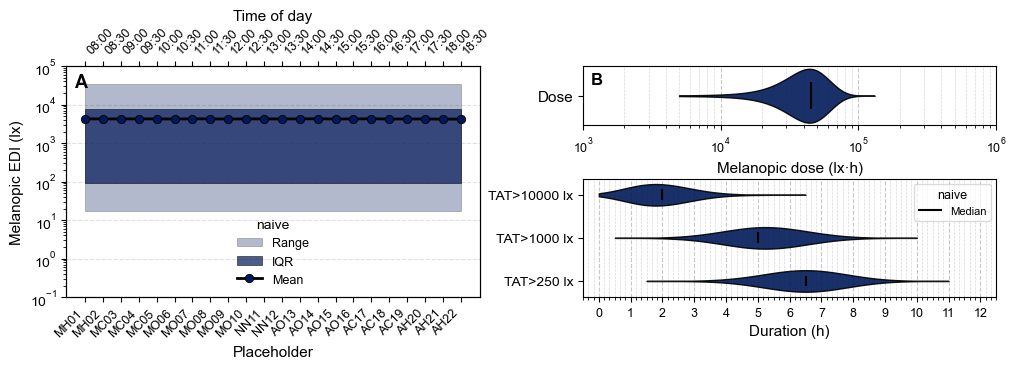

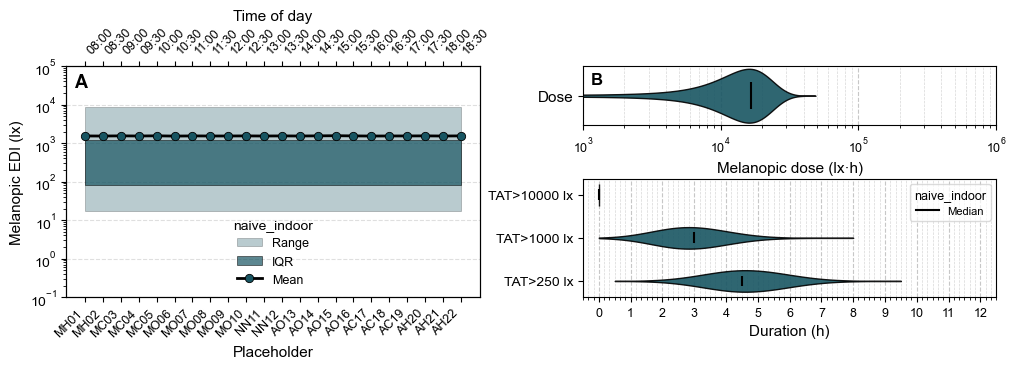

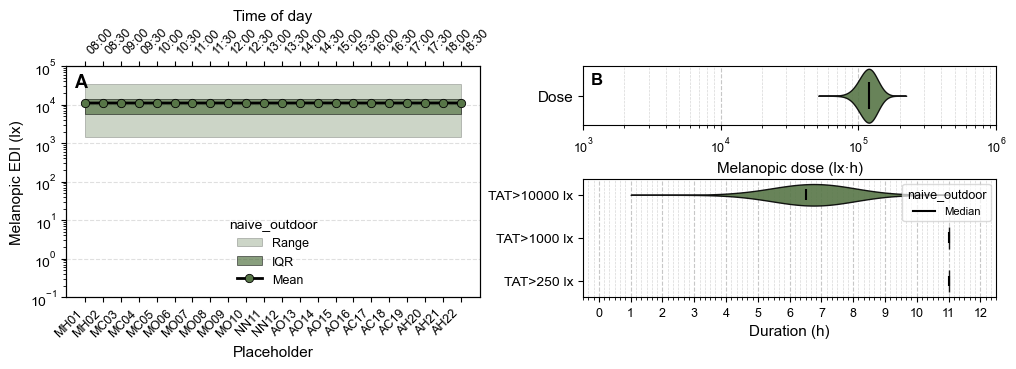

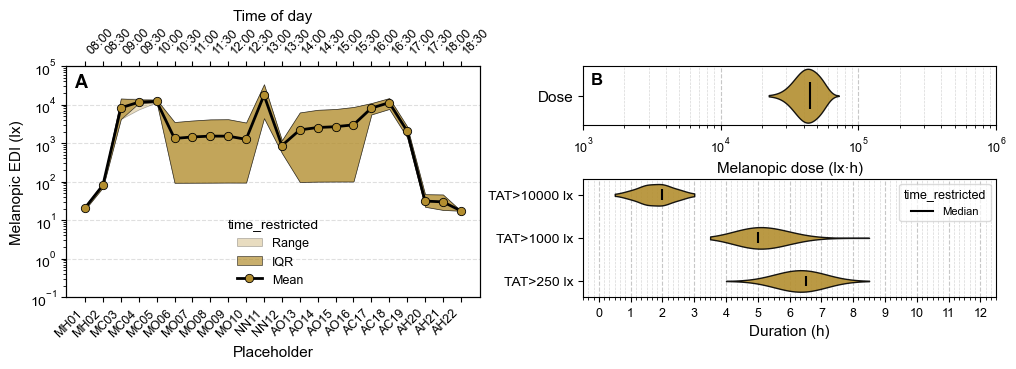

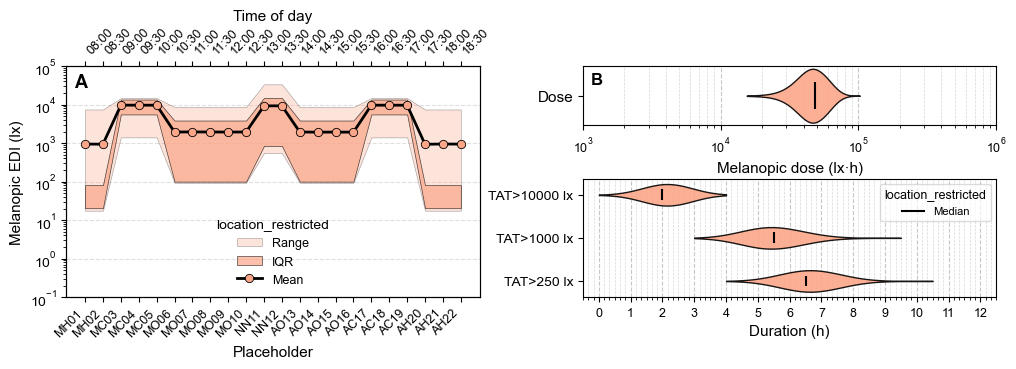

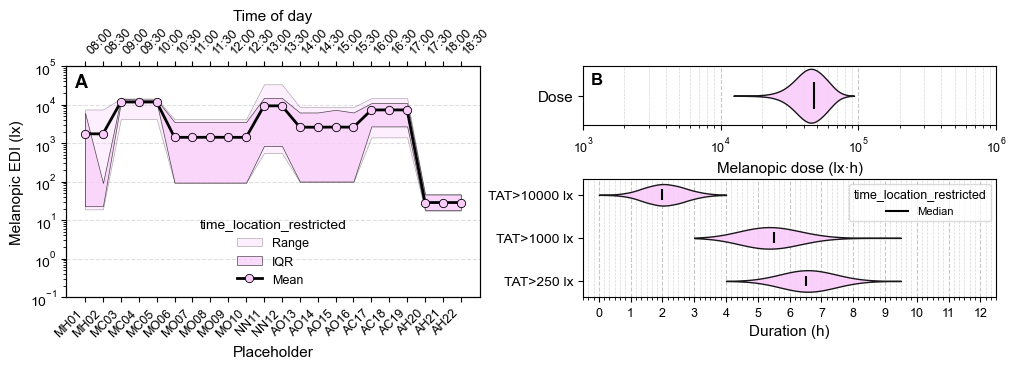

In [53]:
## Create a plot with two subplots consist of Distribution + Metrics for each model.

save_dir = os.path.join(root_dir, "results", "plots")
dpi = 300

for i, model_name in enumerate(model_order):
    fig = plt.figure(figsize=(12, 3))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.25)

    # Left panel: one axis
    ax_dist = fig.add_subplot(gs[0, 0])

    # Right panel: split into two stacked axes
    gs_right = gs[0, 1].subgridspec(2, 1, height_ratios=[1, 2], hspace=0.6)
    ax_dose = fig.add_subplot(gs_right[0, 0])
    ax_duration = fig.add_subplot(gs_right[1, 0])

    color_pos = i / max(len(model_order) - 1, 1)
    base_color = cm.batlow(color_pos)

    # --- A: Distribution plot ---
    plot_model_timeline_iqr(
        sequence_dict[model_name],
        placeholders=placeholders,
        times=times,
        base_color=base_color,
        metric_name="Melanopic EDI (lx)",
        sequences_name=model_name,
        ax=ax_dist,
        save=False,
        add_top_axis=True,
        show_legend=True,
    )

    ax_dist.text(
        0.02, 0.97, "A",
        transform=ax_dist.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

    # --- B: Metrics plot ---
    plot_model_metrics_violin(
        metrics_dict[model_name],
        model_name=model_name,
        color=base_color,
        ax=[ax_dose, ax_duration],
        save_dir=None
    )

    ax_dose.text(
        0.02, 0.90, "B",
        transform=ax_dose.transAxes,
        va="top", ha="left",
        fontsize=12, fontweight="bold"
    )

    fig.savefig(
        os.path.join(save_dir, f"Combined_{model_name}.png"),
        bbox_inches="tight",
        dpi=dpi
    )
    fig.savefig(
        os.path.join(save_dir, f"Combined_{model_name}.pdf"),
        bbox_inches="tight"
    )


## Model comparison

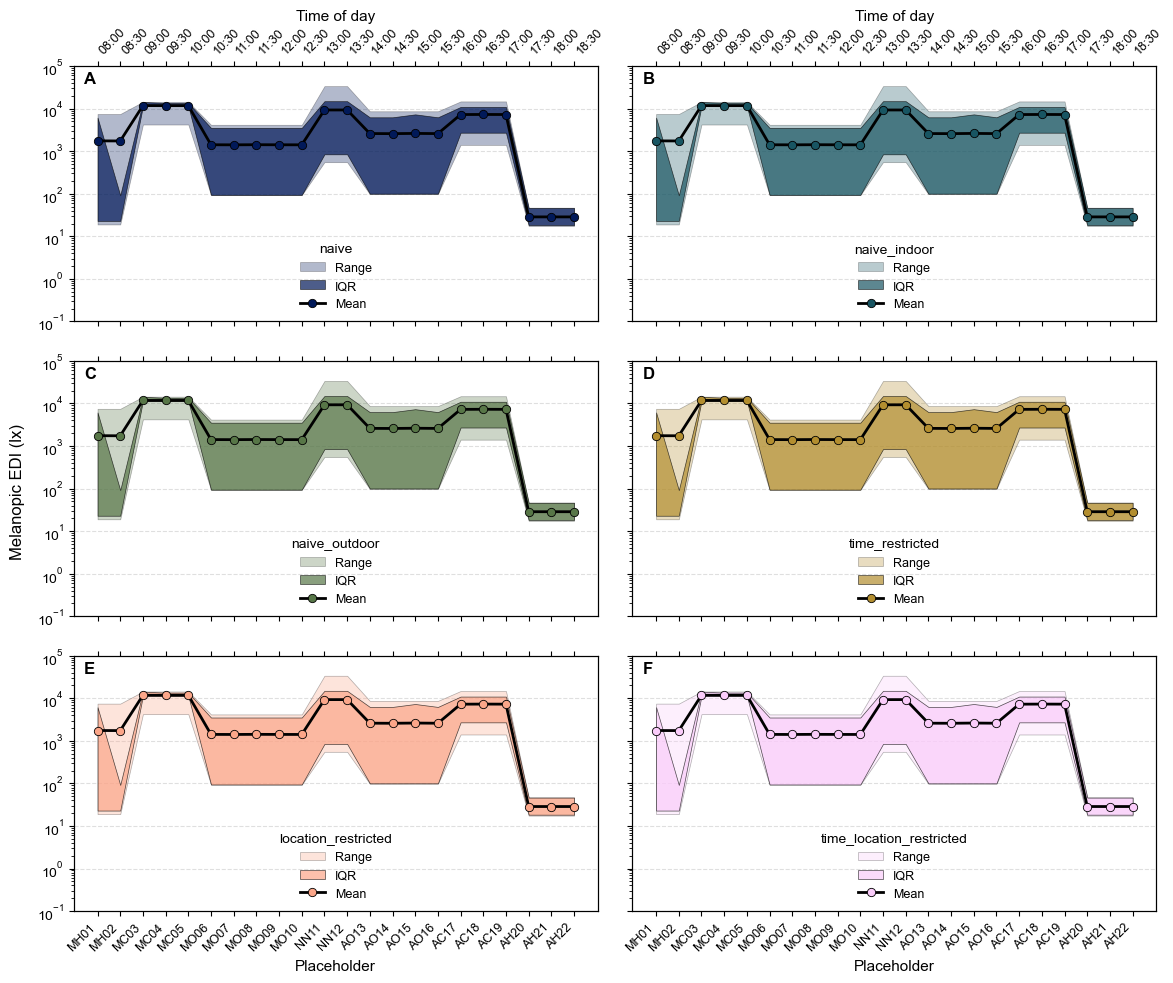

In [54]:
# Plot distribution of average melanopic EDI for six synthetic models throughout a synthetic day in one grid

# Model sequences as inputs
keys = list(sequence_dict.keys())
n = len(keys)
if n > 6:
    raise ValueError("Grid supports up to 6 models (3×2).")

# Grid 3*2
fig, axs = plt.subplots(3, 2, figsize=(12, 10), sharey=True)
axs = axs.flatten()
colors = [cm.batlow(i / max(n - 1, 1)) for i in range(n)]
metric_name = "Melanopic EDI (lx)"

for i, ax in enumerate(axs):
    if i >= n:
        ax.axis("off")
        continue

    key = keys[i]
    base_color = colors[i]

    # plot into this axis; do NOT save individual plots
    _, ax_top = plot_model_timeline_iqr(
        sequence_dict[model_name],
        placeholders=placeholders,
        times=times,
        base_color=base_color,
        metric_name="Melanopic-EDI (lx)",
        sequences_name=key,
        ax=ax,
        save=False,
        add_top_axis=True,
        show_legend=True,
    )

    # panel label
    ax.text(0.02, 0.98, "ABCDEF"[i], transform=ax.transAxes,
            va="top", ha="left", fontsize=12, fontweight="bold")

    row, col = divmod(i, 2)

    # bottom x labels only on last row
    if row < 2:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    # top x labels only on first row
    if ax_top is not None and row > 0:
        ax_top.set_xlabel("")
        ax_top.tick_params(axis="x", labeltop=False)

    # y tick labels only on left column; no per-panel y-label
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelleft=(col == 0))

# shared y label + save
fig.supylabel(metric_name, fontsize=12)
fig.tight_layout()
fig.savefig(
    os.path.join(root_dir, "results", "plots", "Models_distribution_grid.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "Models_distribution_grid.pdf"),
    dpi=300
)

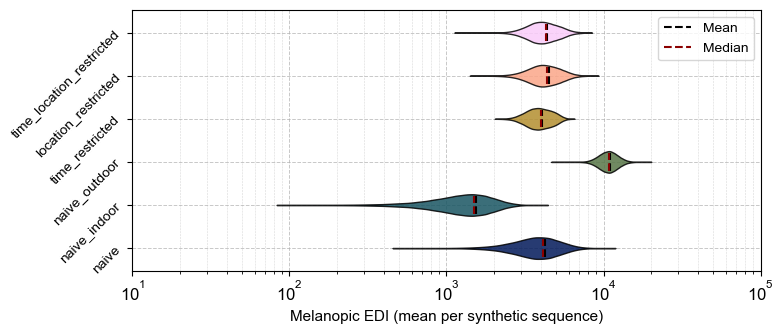

In [55]:
# Violin plot of distribution of mean melanopic EDI for synthetic models

# Path of synthetic sequences
folder = os.path.join(root_dir, "results", "tables", "sequences")

# exact order of files (the unique part of filename before .csv)
model_order = [ 
    "naive_melanopic_sequence",
    "naive_indoor_melanopic_sequence",
    "naive_outdoor_melanopic_sequence",
    "time_restricted_melanopic_sequence",
    "location_restricted_melanopic_sequence",
    "time_location_restricted_melanopic_sequence"
]

all_model_means = []
model_labels = []

for model_name in model_order:
    # construct the full filename (assuming *.csv)
    fname = [f for f in os.listdir(folder) if model_name in f.lower()]
    if len(fname) == 0:
        continue  # skip missing files
    fname = fname[0]  # take the first match
    label = fname.lower().replace(".csv", "")  # label for plot
    model_labels.append(label)

    # read CSV memory-safe
    df = pd.read_csv(os.path.join(folder, fname))
    df_numeric = df.iloc[:, 1:]  # drop first column (non-numeric index)
    col_means = df_numeric.mean(axis=0).values
    all_model_means.append(col_means)

    del df, df_numeric
    gc.collect()

# ----------------- PLOT -----------------
fig, ax = plt.subplots(figsize=(8, 3.5))
n = len(all_model_means)

# put grid behind
ax.set_axisbelow(True)

# categorical colors
colors = [cmap(i / (n - 1)) for i in range(n)] if n > 1 else [cmap(0.5)]

# violins
parts = ax.violinplot(all_model_means, showmeans=False, showextrema=False, vert=False)

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(colors[i])
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)  # put violins above grid
# mean and median lines
for i, col in enumerate(all_model_means):
    pos = i + 1
    mean_val = np.mean(col)
    median_val = np.median(col)
    ax.plot( [mean_val, mean_val], [pos - 0.2, pos + 0.2], color='black', linewidth=1.5, linestyle='--', label='Mean' if i==0 else "", zorder=3)
    ax.plot( [median_val, median_val], [pos - 0.2, pos + 0.2], color='darkred', linewidth=1.5, linestyle='--', label='Median' if i==0 else "", zorder=3)

# x-axis labels: remove '_melanopic_sequence'

ax.set_xscale("log")
ax.set_xlim(1e1, 1e5)
ax.set_xlabel("Melanopic EDI (mean per synthetic sequence)", fontsize=11)


# y-axis log scale and grid `if i want to ordered y axis top to bottom: (ax.invert_yaxis()),`
y_labels = [label.replace("_melanopic_sequence", "") for label in model_labels]
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(y_labels, ha="right", fontsize=10, rotation=45)

# Grid: major + minor (minor now truly logarithmic)
ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7, zorder=1)
ax.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.5, zorder=1)

# legend
mean_line = Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Mean')
median_line = Line2D([0], [0], color='darkred', linewidth=1.5, linestyle='--', label='Median')
ax.legend(handles=[mean_line, median_line], loc='upper right', fontsize=10)

plt.tight_layout()
fig.savefig(
    os.path.join(root_dir, "results", "plots", "Comparison_violin_plot_mean_melanopic_distribution.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "Comparison_violin_plot_mean_melanopic_distribution.pdf"),
    dpi=300
)

## Real world light exposure dataset


In [56]:
# read CSV
real_world_df = pd.read_csv(
    os.path.join(root_dir, "data", "real_world_dataset.csv")
)
# Add time if missing
real_world_df["Datetime"] = real_world_df["Datetime"].apply(
    lambda x: x if ":" in x else f"{x} 00:00"
)
real_world_df["Datetime"] = pd.to_datetime(real_world_df["Datetime"], format="%d.%m.%Y %H:%M")
real_world_df.head()

,Id,Datetime,MEDI,Site
0,MY001,2023-11-23 00:00:00,0.100000,Malaysia
1,MY001,2023-11-23 00:30:00,0.847385,Malaysia
2,MY001,2023-11-23 01:00:00,0.597608,Malaysia
3,MY001,2023-11-23 01:30:00,0.100000,Malaysia
4,MY001,2023-11-23 02:00:00,0.100000,Malaysia


In [57]:
df_day = real_world_df[
    (real_world_df["Datetime"].dt.time >= pd.to_datetime("08:00").time()) &
    (real_world_df["Datetime"].dt.time <= pd.to_datetime("18:30").time())
]
df_day = df_day[df_day["MEDI"] >= 0.9]


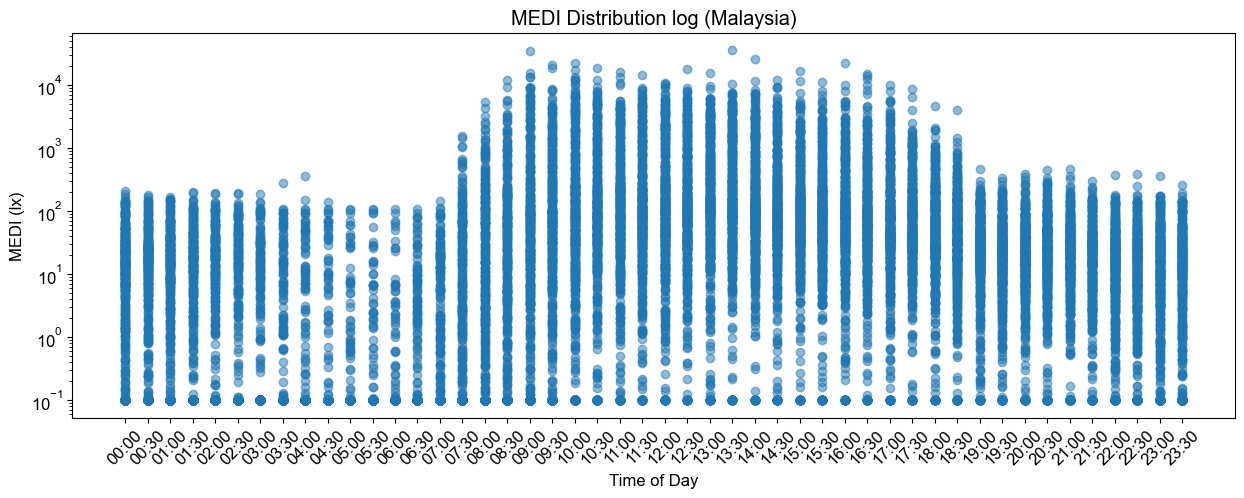

In [58]:
df_malaysia = real_world_df[real_world_df["Site"] == "Malaysia"].copy()

df_malaysia["time"] = df_malaysia["Datetime"].dt.strftime("%H:%M")

plt.figure(figsize=(15, 5))
plt.scatter(df_malaysia["time"], df_malaysia["MEDI"], alpha=0.5)
plt.yscale("log")
plt.xlabel("Time of Day")
plt.ylabel("MEDI (lx)")
plt.title("MEDI Distribution log (Malaysia)")
plt.xticks(rotation=45);


In [59]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())

all_site_values = []
site_labels = []

for site in sites:
    vals = df_day.loc[df_day["Site"] == site, "MEDI"].dropna().values
    if len(vals) == 0:
        continue
    all_site_values.append(vals)
    site_labels.append(site)

In [60]:
# Group by site and get min/max with corresponding times
site_summary = []

for site in df_day["Site"].unique():
    df_site = df_day[df_day["Site"] == site]
    if df_site.empty:
        continue

    total_count = len(df_site)
    
    # min MEDI and its datetime
    min_idx = df_site["MEDI"].idxmin()
    min_val = df_site.loc[min_idx, "MEDI"]
    min_time = df_site.loc[min_idx, "Datetime"]

    # max MEDI and its datetime
    max_idx = df_site["MEDI"].idxmax()
    max_val = df_site.loc[max_idx, "MEDI"]
    max_time = df_site.loc[max_idx, "Datetime"]

    # percentage of MEDI < 1
    pct_below_1 = (df_site["MEDI"] < 1).sum() / total_count * 100

    # percentage of MEDI < 10
    pct_below_10 = (df_site["MEDI"] < 10).sum() / total_count * 100

    site_summary.append({
        "Site": site,
        "Min_MEDI": min_val,
        "Min_time": min_time,
        "Max_MEDI": max_val,
        "Max_time": max_time,
        "%_below_1": pct_below_1,
        "%_below_10": pct_below_10
    })

# Convert to DataFrame
site_summary_df = pd.DataFrame(site_summary)
site_summary_df

,Site,Min_MEDI,Min_time,Max_MEDI,Max_time,%_below_1,%_below_10
0,Malaysia,0.901142,2023-12-12 18:00:00,35503.10340,2023-12-18 13:30:00,0.266489,11.847657
1,Switzerland,0.907988,2023-08-11 16:30:00,79336.33223,2023-09-05 10:30:00,0.221324,8.804850
2,UK,0.912043,2023-06-03 08:30:00,110922.18580,2022-06-22 13:00:00,0.112376,9.012586
3,Germany,0.901167,2023-11-03 08:30:00,60324.17272,2024-07-09 12:30:00,0.091013,10.034130
4,Turkey,0.903222,2025-03-02 09:30:00,25512.16606,2025-04-30 12:00:00,0.240154,7.444765
5,Spain,0.928556,2024-12-10 18:30:00,35341.78839,2024-11-17 14:30:00,0.104239,6.914524
6,Ghana,0.912389,2024-11-28 08:00:00,57183.93478,2024-11-30 12:00:00,0.308642,21.419753
7,Costa Rica,0.910889,2025-07-01 17:00:00,31267.87439,2025-07-24 09:30:00,0.129702,7.111976


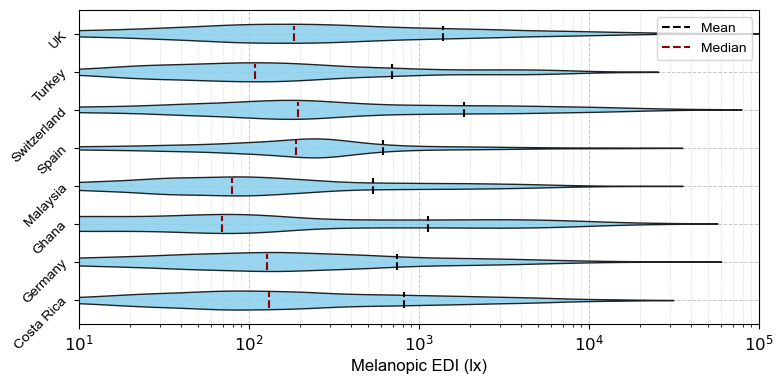

In [61]:
fig, ax = plt.subplots(figsize=(8, 4))
n = len(all_site_values)

ax.set_axisbelow(True)

# --- compute in log space to avoid KDE boundary cut ---
log_all_site_values = [np.log10(vals) for vals in all_site_values]

# Horizontal violins (in log10 space)
parts = ax.violinplot(
    log_all_site_values,
    showmeans=False,
    showextrema=False,
    vert=False
)

# color and style
for body in parts["bodies"]:
    body.set_facecolor("skyblue")
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)

# Mean and median lines (also in log10 space)
for i, vals in enumerate(all_site_values):
    pos = i + 1
    mean_val = np.log10(np.mean(vals))
    median_val = np.log10(np.median(vals))

    ax.plot([mean_val, mean_val], [pos - 0.2, pos + 0.2],
            color="black", linewidth=1.5, linestyle="--", label="Mean" if i == 0 else "", zorder=3)

    ax.plot([median_val, median_val], [pos - 0.2, pos + 0.2],
            color="darkred", linewidth=1.5, linestyle="--", label="Median" if i == 0 else "", zorder=3)

# Y-axis labels
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(site_labels, fontsize=10, rotation=45)

# Limits: 1e1 to 1e5 (in log10 space: 1 to 5)
xmin, xmax = np.log10(1e1), np.log10(1e5)
ax.set_xlim(xmin, xmax)

# Major ticks at integer log10 positions
ax.xaxis.set_major_locator(MultipleLocator(1))

# Minor ticks at log10(2..9) within each decade (true log-style minors)
subs = np.log10(np.arange(2, 10))  # log10(2..9)
decades = np.arange(np.floor(xmin), np.ceil(xmax))  # 1..4 for 10^1..10^5 span
minor_ticks = (decades[:, None] + subs[None, :]).ravel()
minor_ticks = minor_ticks[(minor_ticks >= xmin) & (minor_ticks <= xmax)]
ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))

# Major labels as 10^k
def pow10_tex_formatter(x, pos):
    k = int(np.round(x))
    if np.isclose(x, k, atol=1e-8):
        return rf"$10^{{{k}}}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(pow10_tex_formatter))

ax.set_xlabel("Melanopic EDI (lx)")
# ax.set_title("Daytime MEDI Distributions by Site")

# Grid: major + minor (minor now truly logarithmic)
ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7, zorder=1)
ax.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.5, zorder=1)

# Legend
mean_line = Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", label="Mean")
median_line = Line2D([0], [0], color="darkred", linewidth=1.5, linestyle="--", label="Median")
ax.legend(handles=[mean_line, median_line], loc="upper right",  fontsize=10)

plt.tight_layout()
fig.savefig(
    os.path.join(root_dir, "results", "plots", "real_world_violin_plot_mean_melanopic_distribution.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "real_world_violin_plot_mean_melanopic_distribution.pdf"),
    dpi=300
)

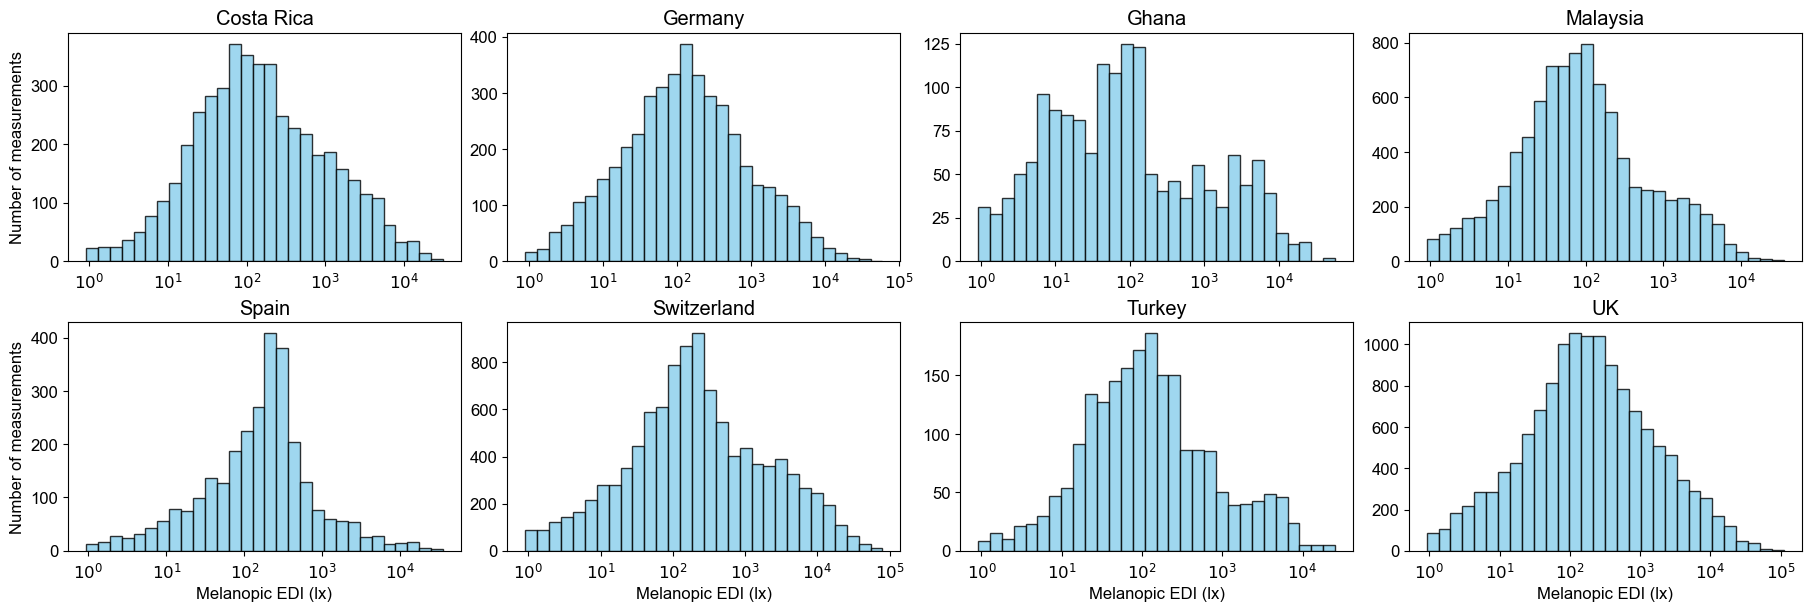

In [62]:
sites = sorted(df_day["Site"].unique())
n_sites = len(sites)

fig, axes = plt.subplots(2, 4, figsize=(18, 6), constrained_layout=True)
axes = axes.flatten()

def pow10_tex_formatter(x, pos):
    k = int(np.round(x))
    if np.isclose(x, k, atol=1e-8):
        return rf"$10^{{{k}}}$"
    return ""

for i, site in enumerate(sites):
    vals = df_day.loc[df_day["Site"] == site, "MEDI"].values
    vals = vals[vals > 0]

    log_vals = np.log10(vals)

    ax = axes[i]

    ax.hist(
        log_vals,
        bins=30,
        color="skyblue",
        edgecolor="black",
        alpha=0.8
    )

    ax.xaxis.set_major_formatter(FuncFormatter(pow10_tex_formatter))

    ax.set_title(site)

    # show x label only for bottom row
    if i // 4 == 1:
        ax.set_xlabel("Melanopic EDI (lx)")
    else:
        ax.set_xlabel("")

    # show y label only for first column
    if i % 4 == 0:
        ax.set_ylabel("Number of measurements")
    else:
        ax.set_ylabel("")

# remove empty subplots
for j in range(n_sites, 8):
    fig.delaxes(axes[j])

fig.savefig(
    os.path.join(root_dir, "results", "plots", "real_world_hist.png"),
    dpi=300
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "real_world_hist.pdf"),
    dpi=300
)


In [63]:
from matplotlib.backends.backend_pdf import PdfPages
from pdf2image import convert_from_path

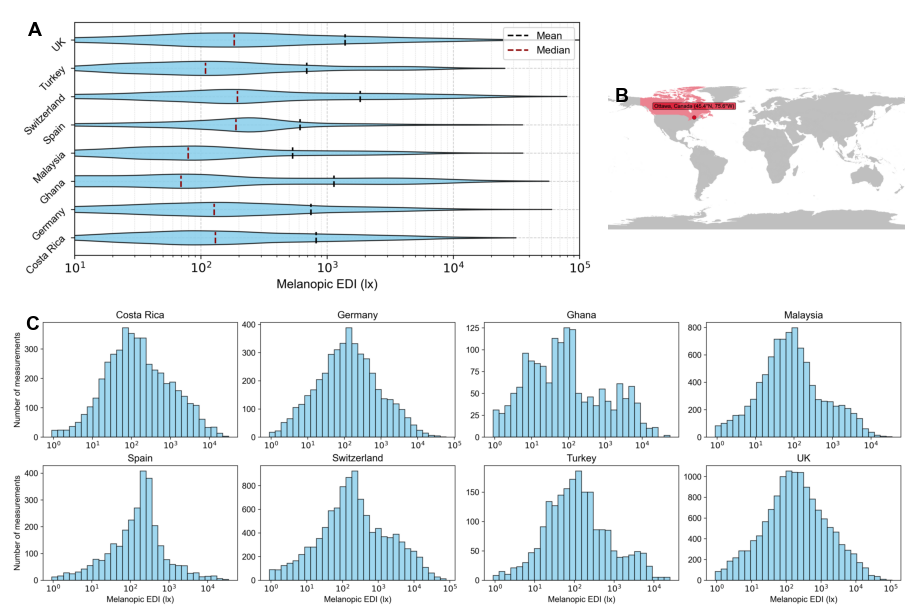

In [64]:

# paths
p1 = os.path.join(root_dir, "results", "plots", "real_world_violin_plot_mean_melanopic_distribution.png")
p2 = os.path.join(root_dir, "results", "plots", "LightLogR", "worldmap.pdf")
p3 = os.path.join(root_dir, "results", "plots", "real_world_hist.png")

# read images
im1 = Image.open(p1)
im2 = convert_from_path(p2, first_page=1, last_page=1)[0]
im3 = Image.open(p3)

# figure layout: 2 rows, 3 columns
# A spans 2 columns, B spans 1 column, C spans all 3 columns
fig = plt.figure(figsize=(9, 6))

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1]
)

ax1 = fig.add_subplot(gs[0, 0:2])  # A: 2/3 width
ax2 = fig.add_subplot(gs[0, 2])    # B: 1/3 width
ax3 = fig.add_subplot(gs[1, :])    # C: full width

ax1.imshow(im1)
ax2.imshow(im2)
ax3.imshow(im3)

for ax in [ax1, ax2, ax3]:
    ax.axis("off")

# panel labels
ax1.text(0.03, 0.96, "A", transform=ax1.transAxes,
         ha="left", va="top", fontsize=14, fontweight="bold")

ax2.text(0.02, 0.99, "B", transform=ax2.transAxes,
         ha="left", va="top", fontsize=14, fontweight="bold")

ax3.text(0.015, 0.98, "C", transform=ax3.transAxes,
         ha="left", va="top", fontsize=14, fontweight="bold")

plt.tight_layout(pad=0.1, w_pad=0.2, h_pad=0.2)

fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_real_world.png"),
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    os.path.join(root_dir, "results", "plots", "plot_real_world.pdf"),
    dpi=300,
    bbox_inches="tight"
)

In [257]:
june_real_world_df = real_world_df[real_world_df["Datetime"].dt.month.isin([5, 6, 7])
]

In [258]:
df_day = june_real_world_df[
    (june_real_world_df["Datetime"].dt.time >= pd.to_datetime("08:00").time()) &
    (june_real_world_df["Datetime"].dt.time <= pd.to_datetime("18:30").time())
]
df_day = df_day[df_day["MEDI"] >= 0.9]

In [259]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())

all_site_values = []
site_labels = []

for site in sites:
    vals = df_day.loc[df_day["Site"] == site, "MEDI"].dropna().values
    if len(vals) == 0:
        continue
    all_site_values.append(vals)
    site_labels.append(site)

In [260]:
# Group by site and get min/max with corresponding times
site_summary = []

for site in df_day["Site"].unique():
    df_site = df_day[df_day["Site"] == site]
    if df_site.empty:
        continue

    total_count = len(df_site)
    
    # min MEDI and its datetime
    min_idx = df_site["MEDI"].idxmin()
    min_val = df_site.loc[min_idx, "MEDI"]
    min_time = df_site.loc[min_idx, "Datetime"]

    # max MEDI and its datetime
    max_idx = df_site["MEDI"].idxmax()
    max_val = df_site.loc[max_idx, "MEDI"]
    max_time = df_site.loc[max_idx, "Datetime"]

    # percentage of MEDI < 1
    pct_below_1 = (df_site["MEDI"] < 1).sum() / total_count * 100

    # percentage of MEDI < 10
    pct_below_10 = (df_site["MEDI"] < 10).sum() / total_count * 100

    site_summary.append({
        "Site": site,
        "Min_MEDI": min_val,
        "Min_time": min_time,
        "Max_MEDI": max_val,
        "Max_time": max_time,
        "%_below_1": pct_below_1,
        "%_below_10": pct_below_10
    })

# Convert to DataFrame
site_summary_df = pd.DataFrame(site_summary)
site_summary_df

,Site,Min_MEDI,Min_time,Max_MEDI,Max_time,%_below_1,%_below_10
0,Switzerland,1.703758,2023-07-30 09:00:00,46527.11313,2023-07-31 12:00:00,0.000000,3.292181
1,UK,0.912043,2023-06-03 08:30:00,110922.18580,2022-06-22 13:00:00,0.093746,9.843311
2,Germany,0.951722,2024-07-12 14:30:00,60324.17272,2024-07-09 12:30:00,0.082713,7.196030
3,Turkey,1.385889,2025-05-01 18:30:00,13774.68428,2025-05-02 13:30:00,0.000000,8.374384
4,Costa Rica,0.910889,2025-07-01 17:00:00,31267.87439,2025-07-24 09:30:00,0.149869,7.418509


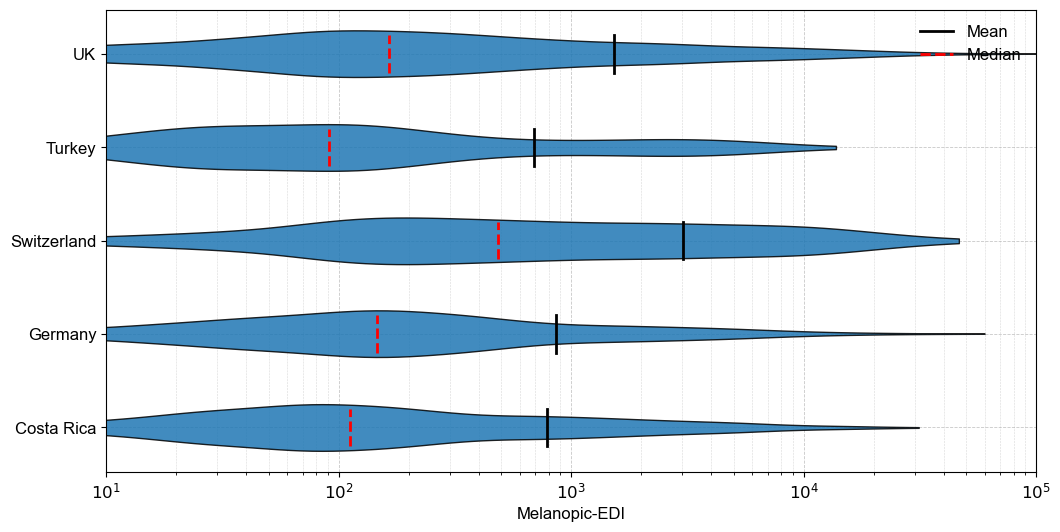

In [261]:
fig, ax = plt.subplots(figsize=(12, 6))
n = len(all_site_values)

ax.set_axisbelow(True)

# --- compute in log space to avoid KDE boundary cut ---
log_all_site_values = [np.log10(vals) for vals in all_site_values]

# Horizontal violins (in log10 space)
parts = ax.violinplot(
    log_all_site_values,
    showmeans=False,
    showextrema=False,
    vert=False
)

# color and style
for body in parts["bodies"]:
    body.set_facecolor("tab:blue")
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)

# Mean and median lines (also in log10 space)
for i, vals in enumerate(all_site_values):
    pos = i + 1
    mean_val = np.log10(np.mean(vals))
    median_val = np.log10(np.median(vals))

    ax.plot([mean_val, mean_val], [pos - 0.2, pos + 0.2],
            color="black", linewidth=2, label="Mean" if i == 0 else "", zorder=3)

    ax.plot([median_val, median_val], [pos - 0.2, pos + 0.2],
            color="red", linewidth=2, linestyle="--", label="Median" if i == 0 else "", zorder=3)

# Y-axis labels
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(site_labels)

# Limits: 1e1 to 1e5 (in log10 space: 1 to 5)
xmin, xmax = np.log10(1e1), np.log10(1e5)
ax.set_xlim(xmin, xmax)

# Major ticks at integer log10 positions
ax.xaxis.set_major_locator(MultipleLocator(1))

# Minor ticks at log10(2..9) within each decade (true log-style minors)
subs = np.log10(np.arange(2, 10))  # log10(2..9)
decades = np.arange(np.floor(xmin), np.ceil(xmax))  # 1..4 for 10^1..10^5 span
minor_ticks = (decades[:, None] + subs[None, :]).ravel()
minor_ticks = minor_ticks[(minor_ticks >= xmin) & (minor_ticks <= xmax)]
ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))

# Major labels as 10^k
def pow10_tex_formatter(x, pos):
    k = int(np.round(x))
    if np.isclose(x, k, atol=1e-8):
        return rf"$10^{{{k}}}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(pow10_tex_formatter))

ax.set_xlabel("Melanopic-EDI")
# ax.set_title("Daytime MEDI Distributions by Site")

# Grid: major + minor (minor now truly logarithmic)
ax.grid(which="major", linestyle="--", linewidth=0.6, alpha=0.7, zorder=1)
ax.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.5, zorder=1)

# Legend
mean_line = Line2D([0], [0], color="black", linewidth=2, label="Mean")
median_line = Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Median")
ax.legend(handles=[mean_line, median_line], loc="upper right", frameon=False)

Text(0.5, 0.98, 'MEDI Distributions per Site\n(linear bins in log space)')

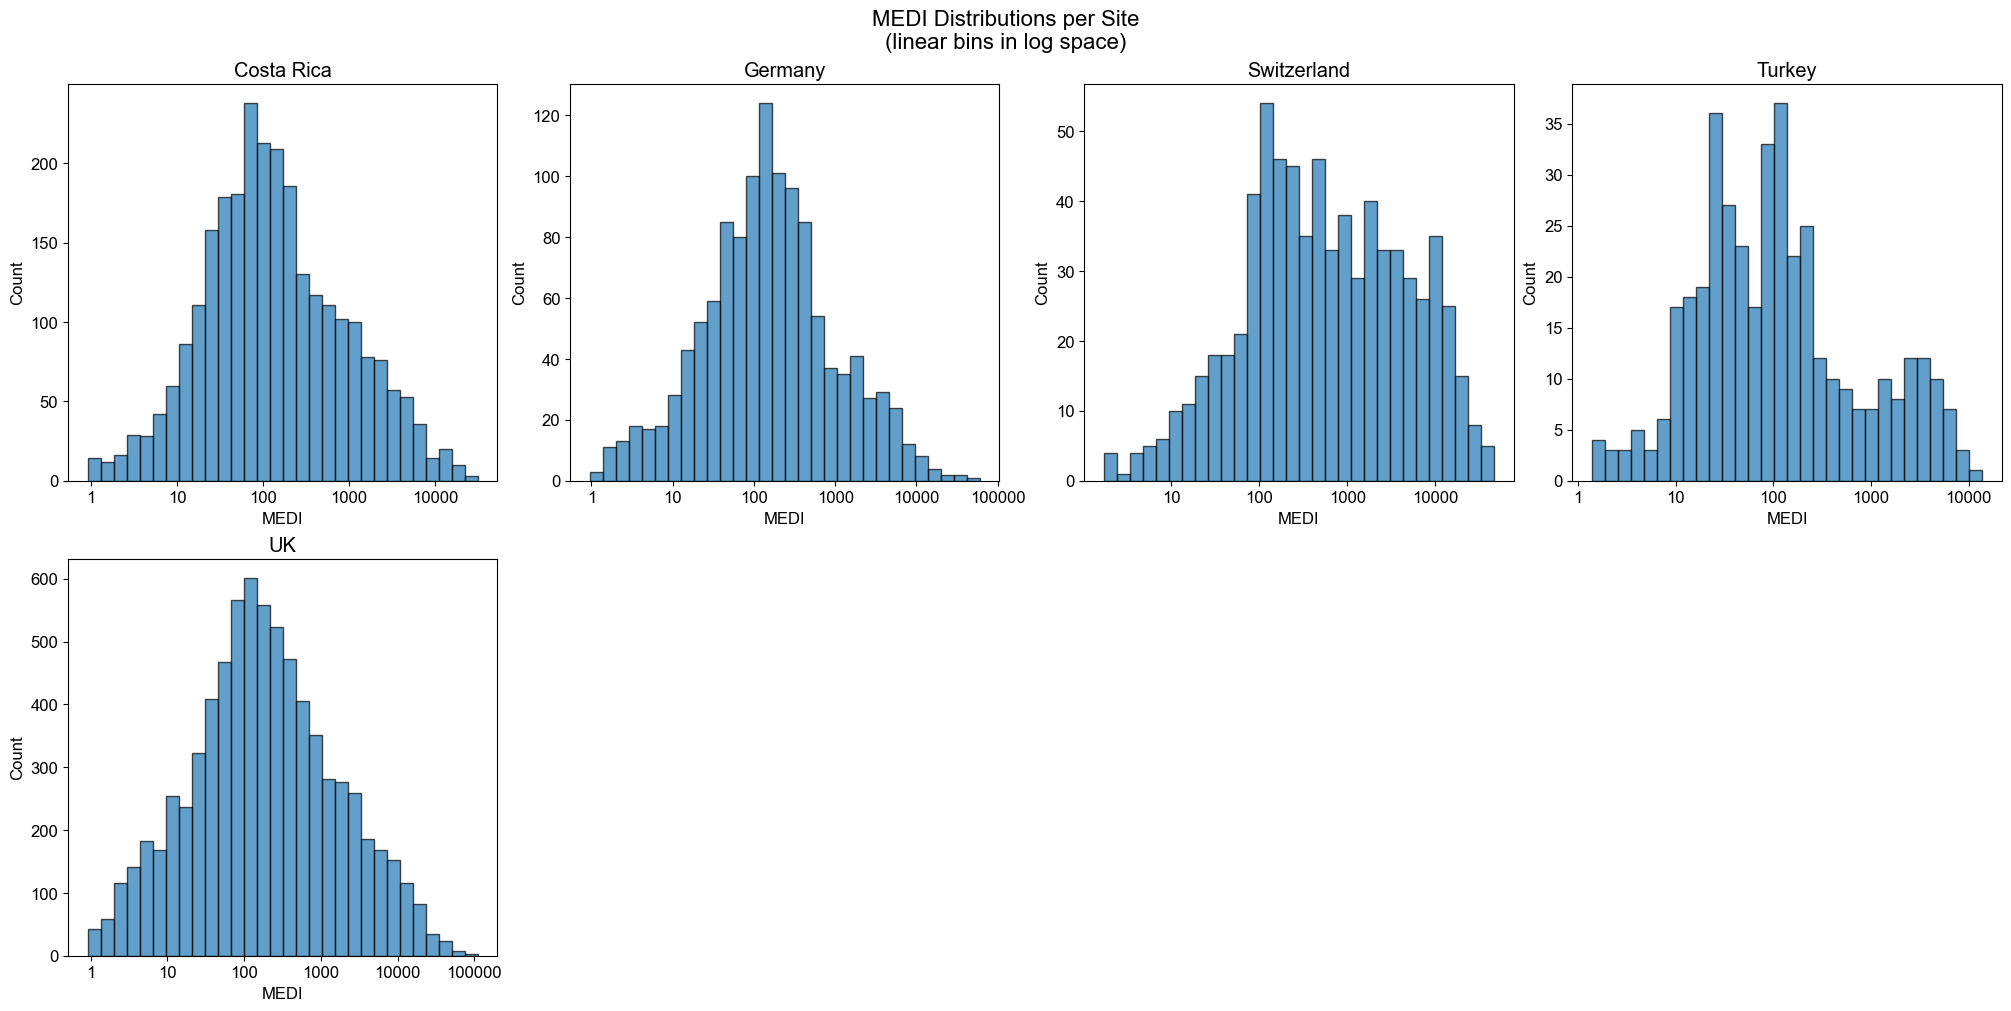

In [262]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())
n_sites = len(sites)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten()

# formatter: convert log10(MEDI) -> MEDI label
def log_to_medi_formatter(x, pos):
    return f"{10**x:.0f}"

for i, site in enumerate(sites):
    vals = df_day[df_day["Site"] == site]["MEDI"].values
    vals = vals[vals > 0]

    log_vals = np.log10(vals)

    axes[i].hist(
        log_vals,
        bins=30,
        color="tab:blue",
        edgecolor="black",
        alpha=0.7
    )

    axes[i].xaxis.set_major_formatter(FuncFormatter(log_to_medi_formatter))

    axes[i].set_title(site)
    axes[i].set_xlabel("MEDI")
    axes[i].set_ylabel("Count")

# remove empty subplots
for j in range(n_sites, 8):
    fig.delaxes(axes[j])

plt.suptitle(
    "MEDI Distributions per Site\n(linear bins in log space)",
    fontsize=16
)

In [242]:
# Create and save data tree for project folder

output_file = os.path.join(root_dir, "results", "datatree.txt")

lines = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Skip hidden folders and files (like .git, .ipynb_checkpoints, etc.)
    dirnames[:] = [d for d in sorted(dirnames) if not d.startswith('.')]
    filenames = [f for f in sorted(filenames) if not f.startswith('.')]

    rel_path = os.path.relpath(dirpath, root_dir)
    depth = 0 if rel_path == "." else rel_path.count(os.sep) + 1
    indent = "│   " * (depth - 1)

    # Folder name
    folder_name = os.path.basename(dirpath) if rel_path != "." else os.path.basename(os.path.normpath(root_dir))
    lines.append(f"{indent}{folder_name}/")

    # Files inside folder
    for i, file in enumerate(filenames):
        connector = "└── " if i == len(filenames) - 1 else "├── "
        lines.append(f"{indent}    {connector}{file}")

tree_text = "\n".join(lines)

# Save to file
with open(output_file, "w", encoding="utf-8") as f:
    f.write(tree_text)
    
